---
# <div align="center"><font color='green'> COSC 2673/2793 |  Machine Learning | Assignment 2 </font></div>
## <div align="center"> <font color='green'> Project 1: Classify Images of Colon Cancer       </font></div>
## <div align="center"> <font color='red'> Student Name: Doan Phan Thuy Trang | Pham Dung Minh Nhan                               </font></div>
## <div align="center"> <font color='red'> Student number: s4027648 | s3975793       </font></div>
---

# Problem statement

In this project, we aim to develop an end-to-end machine learning system to tackle a real-world medical image classification task. The dataset contains labeled 27x27 RGB histopathology images of colon cells, and our goal is to accurately predict two types of labels: whether a cell is cancerous and its specific cell type. The challenge involves selecting appropriate models, processing high-dimensional image data, evaluating model performance using reliable metrics, and making a justified final model choice through comparative analysis. This project includes two core tasks:

- Task 1: Train and optimize models to classify cancer presence and cell type using the main dataset.

- Task 2: Use additional data to improve the cell-type classification model and justify the final model selection based on performance.

# Data Exploration and Understanding

In [1]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import cv2
import os
import random

# Import the dataset
mainData = pd.read_csv('data/data_labels_mainData.csv') # Main data
extraData = pd.read_csv('data/data_labels_extraData.csv') # Extra data


## Data Cleaning

In this section, data shape, data types, and the first few records were inspected to confirm structure and content. In addition, unique values were analysed to detect inconsistencies. As a result, in Main Data, it was recognised that the cellType and cellTypeName columns have the same total count for each unique value, meaning they represent the same information, which is the name of the cell type. Keeping both columns would cause data leakage. Therefore, this issue will be addressed in the Prevention of Data Leakage section. Besides, the dataset was checked for missing values and duplicate records in CSV files, and no issues were found that require concern.

### Main data (data labels mainData.csv)

In [2]:
# Show the shape of the dataset (main data)
print("Shape of the dataset (main data):", mainData.shape) 

# Show the first few records of the dataset (main data)
print("\nFirst few records (main data):")
mainData.head()

Shape of the dataset (main data): (9896, 6)

First few records (main data):


,InstanceID,patientID,ImageName,cellTypeName,cellType,isCancerous
0,22405,1,22405.png,fibroblast,0,0
1,22406,1,22406.png,fibroblast,0,0
2,22407,1,22407.png,fibroblast,0,0
3,22408,1,22408.png,fibroblast,0,0
4,22409,1,22409.png,fibroblast,0,0


In [3]:
# Check information about the dataset and data types (main data)
print("\nInformation about the dataset (main data):")
mainData.info()


Information about the dataset (main data):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9896 entries, 0 to 9895
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   InstanceID    9896 non-null   int64 
 1   patientID     9896 non-null   int64 
 2   ImageName     9896 non-null   object
 3   cellTypeName  9896 non-null   object
 4   cellType      9896 non-null   int64 
 5   isCancerous   9896 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 464.0+ KB


In [4]:
# Check unique values in each numerical column (main data)
for column in mainData.select_dtypes(include='number').columns:
    print(f"Value counts for {column}:")
    print(mainData[column].value_counts().sort_index())
    print("\n" + "-"*50 + "\n")

Value counts for InstanceID:
InstanceID
1        1
2        1
3        1
4        1
5        1
        ..
22438    1
22439    1
22442    1
22443    1
22444    1
Name: count, Length: 9896, dtype: int64

--------------------------------------------------

Value counts for patientID:
patientID
1      19
2      33
3     136
4     127
5     169
6     198
7     253
8     332
9     348
10    302
11     56
12    130
13    180
14    207
15    125
16    111
17    310
18    320
19    158
20    325
21    224
22    152
23    254
24    192
25    180
26    157
27     17
28     15
29    355
30    110
31    137
32     99
33    163
34     14
35     11
36    128
37     71
38     84
39    105
40    209
41    250
42    136
43    137
44    121
45     74
46    120
47    133
48    147
49    187
50    195
51    286
52    178
53    132
54    389
55    263
56     92
57    149
58    161
59    115
60    115
Name: count, dtype: int64

--------------------------------------------------

Value counts for cellType:
ce

In [5]:
# Check unique values in each object column (main data)
for column in mainData.select_dtypes(include='object').columns:
    print(f"Value counts for {column}:")
    print(mainData[column].value_counts().sort_index())
    print("\n" + "-"*50 + "\n")

Value counts for ImageName:
ImageName
1.png        1
10.png       1
100.png      1
1000.png     1
10000.png    1
            ..
9995.png     1
9996.png     1
9997.png     1
9998.png     1
9999.png     1
Name: count, Length: 9896, dtype: int64

--------------------------------------------------

Value counts for cellTypeName:
cellTypeName
epithelial      4079
fibroblast      1888
inflammatory    2543
others          1386
Name: count, dtype: int64

--------------------------------------------------



In [6]:
# Check for missing values in the dataset (main data)
print("Missing values in the dataset (main data):")
print(mainData.isnull().sum())

# Check for duplicates in the dataset (main data)
print("\nDuplicates in the dataset (main data):")
print(mainData.duplicated().sum())

Missing values in the dataset (main data):
InstanceID      0
patientID       0
ImageName       0
cellTypeName    0
cellType        0
isCancerous     0
dtype: int64

Duplicates in the dataset (main data):
0


### Extra data (data labels extraData.csv)

In [7]:
# Show the shape of the dataset (extra data)
print("Shape of the dataset (extra data):", extraData.shape) 

# Show the first few records of the dataset (extra data)
print("\nFirst few records (extra data):")
extraData.head()

Shape of the dataset (extra data): (10384, 4)

First few records (extra data):


,InstanceID,patientID,ImageName,isCancerous
0,12681,61,12681.png,0
1,12682,61,12682.png,0
2,12683,61,12683.png,0
3,12684,61,12684.png,0
4,12685,61,12685.png,0


In [8]:
# Check information about the dataset and data types (extra data)
print("\nInformation about the dataset (extra data):")
extraData.info()


Information about the dataset (extra data):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10384 entries, 0 to 10383
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   InstanceID   10384 non-null  int64 
 1   patientID    10384 non-null  int64 
 2   ImageName    10384 non-null  object
 3   isCancerous  10384 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 324.6+ KB


In [9]:
# Check unique values in each numerical column (extra data)
for column in extraData.select_dtypes(include='number').columns:
    print(f"Value counts for {column}:")
    print(extraData[column].value_counts().sort_index())
    print("\n" + "-"*50 + "\n")

Value counts for InstanceID:
InstanceID
1631     1
1632     1
1633     1
1634     1
1635     1
        ..
22231    1
22232    1
22233    1
22234    1
22235    1
Name: count, Length: 10384, dtype: int64

--------------------------------------------------

Value counts for patientID:
patientID
61    114
62     93
63     45
64     86
65    326
66    376
67    369
68    422
69    337
70    199
71    290
72     91
73     12
74      8
75     12
77    696
78    409
79    699
80    507
81    365
82    213
83    339
84    316
85    405
86    360
87    342
88    374
89    480
90    416
91    642
92    571
93     78
94     32
95     27
96      6
97    166
98     86
99     75
Name: count, dtype: int64

--------------------------------------------------

Value counts for isCancerous:
isCancerous
0    7394
1    2990
Name: count, dtype: int64

--------------------------------------------------



In [10]:
# Check unique values in each object column (extra data)
for column in extraData.select_dtypes(include='object').columns:
    print(f"Value counts for {column}:")
    print(extraData[column].value_counts().sort_index())
    print("\n" + "-"*50 + "\n")

Value counts for ImageName:
ImageName
10246.png    1
10247.png    1
10248.png    1
10249.png    1
10250.png    1
            ..
9888.png     1
9889.png     1
9890.png     1
9891.png     1
9892.png     1
Name: count, Length: 10384, dtype: int64

--------------------------------------------------



In [11]:
# Check for missing values in the dataset (extra data)
print("Missing values in the dataset (extra data):")
print(extraData.isnull().sum())

# Check for duplicates in the dataset (extra data)
print("\nDuplicates in the dataset (extra data):")
print(extraData.duplicated().sum())

Missing values in the dataset (extra data):
InstanceID     0
patientID      0
ImageName      0
isCancerous    0
dtype: int64

Duplicates in the dataset (extra data):
0


# Dataset Description

The dataset contains 27×27 RGB images of colon cells from 99 patients, split into two CSV files: data_labels_mainData.csv and data_labels_extraData.csv. mainData includes both isCancerous and cellType labels for 60 patients, while extraData includes only isCancerous labels for the remaining 39. These labeled images are used for two classification tasks: detecting cancer presence and identifying specific cell types.

# Task 1:  Detect the presence of cancer in cell images

We preprocess the data by dropping the cellType and cellTypeName columns from the main dataset, then merging it with the extra dataset to increase the number of labeled records. This enhances the dataset and improves the model’s ability to make accurate predictions. Multiple classification models are trained, and the best-performing model is selected and evaluated on a test set to classify whether an image shows cancerous or non-cancerous cells.

## Construct the Data

In [12]:
# Drop the 'cellType' and 'cellTypeName' column from the main data
dataTask1 = mainData.drop(columns=['cellType', 'cellTypeName'])

# Merge the main data with the extra data
dataTask1 = pd.concat([dataTask1, extraData], ignore_index=True)

# Show the shape of the merged dataset
print("Shape of the merged dataset:", dataTask1.shape)

# Check for missing values in the merged dataset
print("\nMissing values in the merged dataset:")
print(dataTask1.isnull().sum())

# Check for duplicates in the merged dataset
print("\nDuplicates in the merged dataset:")
print(dataTask1.duplicated().sum())

# Show the first few records of the merged dataset
print("\nFirst few records of the merged dataset:")
dataTask1.head()


Shape of the merged dataset: (20280, 4)

Missing values in the merged dataset:
InstanceID     0
patientID      0
ImageName      0
isCancerous    0
dtype: int64

Duplicates in the merged dataset:
0

First few records of the merged dataset:


,InstanceID,patientID,ImageName,isCancerous
0,22405,1,22405.png,0
1,22406,1,22406.png,0
2,22407,1,22407.png,0
3,22408,1,22408.png,0
4,22409,1,22409.png,0


=> Based on the shape, since mainData has 9896 records and extraData has 10384 records, the merged dataset contains 20280 records, with no duplicates or missing values.

In [13]:
# Path to the images directory 
image_dir = 'data/patch_images/' 

# Function to return the full image path
def get_image_path(image_name):
    image_path = os.path.join(image_dir, image_name)  # Construct the full path
    if not os.path.exists(image_path):  # Check if the image exists
        print(f"Warning: Image {image_name} not found in {image_dir}") #
        return None  # Return None if the image does not exist
    return image_path

# Add a new column 'ImagePath' with the full image paths
dataTask1['ImagePath'] = dataTask1['ImageName'].apply(get_image_path)

# Display the first few rows to check the new column
dataTask1.head()

,InstanceID,patientID,ImageName,isCancerous,ImagePath
0,22405,1,22405.png,0,data/patch_images/22405.png
1,22406,1,22406.png,0,data/patch_images/22406.png
2,22407,1,22407.png,0,data/patch_images/22407.png
3,22408,1,22408.png,0,data/patch_images/22408.png
4,22409,1,22409.png,0,data/patch_images/22409.png


The dataset was constructed by merging mainData and extraData after dropping the cellType and cellTypeName columns from mainData. Image paths were then appended to each record to enable efficient access during model training. This merged dataset is used for Task 1.

## Split the Data

The dataset is split into 80% training (used to train the model), 10% validation (used for hyperparameter tuning), and 10% test (used for final evaluation). This setup ensures fair evaluation and helps prevent information leakage between training and testing phases. The 80/10/10 split is commonly used in machine learning as it strikes a balance between having enough data to train effectively and ensuring reliable evaluation, especially when the dataset is moderately sized.

In [14]:
from sklearn.model_selection import train_test_split

# First, split into train (80%) and temp (20%)
trainData, temptData = train_test_split(
    dataTask1,
    test_size=0.2,
    stratify=dataTask1['isCancerous'],
    random_state=42
)

# Then split temp into validation (10%) and test (10%)
validationData, testData = train_test_split(
    temptData,
    test_size=0.5,
    stratify=temptData['isCancerous'],
    random_state=42
)

# Print dataset sizes
print("Number of instances in the original dataset is {}. After splitting, Train has {}, Validation has {}, and Test has {} instances."
      .format(dataTask1.shape[0], trainData.shape[0], validationData.shape[0], testData.shape[0]))

Number of instances in the original dataset is 20280. After splitting, Train has 16224, Validation has 2028, and Test has 2028 instances.


### Class Imbalance Identification

To assess class balance in the dataset, we counted the number of cancerous (isCancerous = 1) and non-cancerous (isCancerous = 0) images. The dataset contains:

- Train Set:
    - Non-Cancerous: 10,569 samples
    - Cancerous: 5,655 samples
- Validation Set:
    - Non-Cancerous: 1,321 samples
    - Cancerous: 707 samples
- Test Set:
    - Non-Cancerous: 1,321 samples
    - Cancerous: 707 samples

This indicates a class imbalance, with non-cancerous samples being nearly twice as prevalent as cancerous ones. Such an imbalance can lead to models being biased towards the majority class, potentially limiting their ability to accurately identify cancerous cases. Addressing this imbalance through techniques like augmentation or resampling is essential for developing machine learning models that are both fair and effective, ensuring they generalise well across both cancerous and non-cancerous cell types.

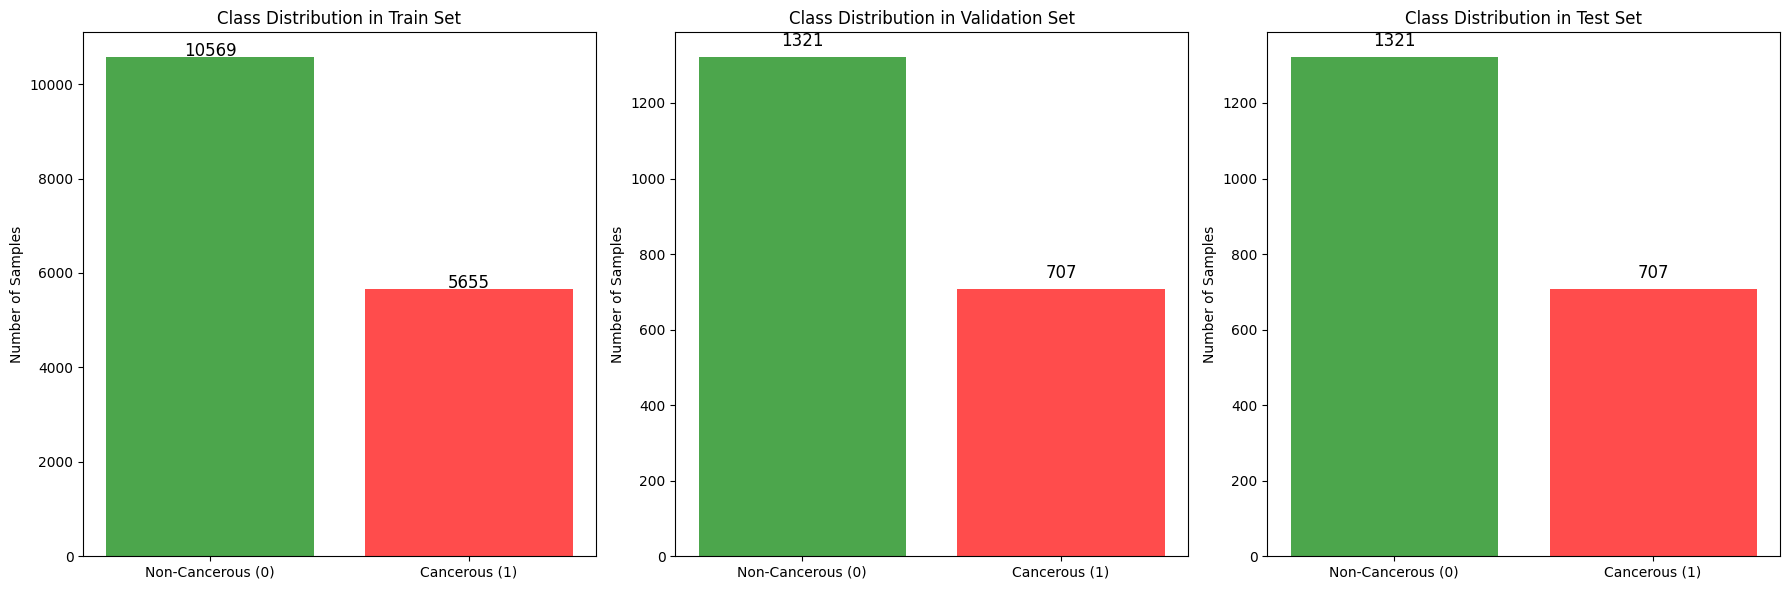

In [15]:
# Function to plot class distribution with value labels on top of bars
def plot_class_distribution(data, split_name, ax):
    countData = data['isCancerous'].value_counts()
    
    # Plot bars with colors: Green for Non-Cancerous (0), Red for Cancerous (1)
    ax.bar(0, countData.get(0, 0), alpha=0.7, color='green', label='Non-Cancerous (0)')
    ax.bar(1, countData.get(1, 0), alpha=0.7, color='red', label='Cancerous (1)')
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-Cancerous (0)', 'Cancerous (1)'])
    ax.set_ylabel('Number of Samples')
    ax.set_title(f'Class Distribution in {split_name} Set')

    # Add value labels on top of the bars
    for i, count in enumerate([countData.get(0, 0), countData.get(1, 0)]):
        ax.text(i, count + 30, str(count), ha='center', fontsize=12)

# Plot distributions for each split
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Train data distribution
plot_class_distribution(trainData, 'Train', axs[0])

# Validation data distribution
plot_class_distribution(validationData, 'Validation', axs[1])

# Test data distribution
plot_class_distribution(testData, 'Test', axs[2])

# Adjust layout
plt.tight_layout()
plt.show()

## Data Augmentation and Transformation

To address the class imbalance in the dataset, we focused on augmenting only the cancerous cell images in the training set. Augmentation techniques such as rotation, zoom, width and height shifts, and horizontal flips were applied to generate new, synthetic images. These augmented samples were then added to the original training data, resulting in a more balanced class distribution between cancerous and non-cancerous cases. By doing so, the model is less likely to become biased toward the non-cancerous class and can more effectively detect cancerous instances, ultimately improving its overall performance and generalisation.

Number of augmented images generated: 4914


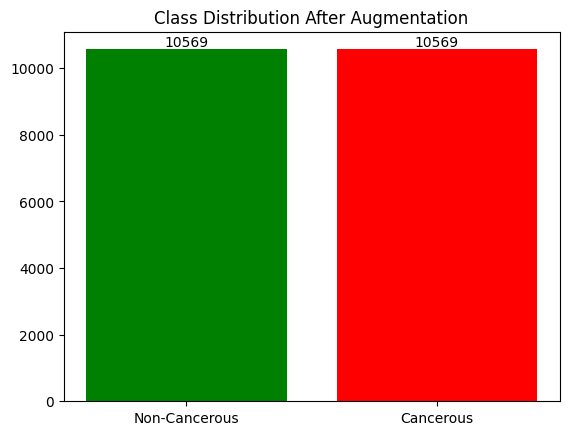

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the augmentation
augmentor = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Extract cancerous samples from trainData
cancerous_data = trainData[trainData['isCancerous'] == 1]
non_cancerous_count = trainData[trainData['isCancerous'] == 0].shape[0]
cancerous_count = cancerous_data.shape[0]

# Number of images to generate
n_to_generate = non_cancerous_count - cancerous_count

# Collect images as a numpy array
cancerous_images = np.array([cv2.imread(image_path) for image_path in cancerous_data['ImagePath']])

# Ensure InstanceID and ImageName columns are strings
trainData['InstanceID'] = trainData['InstanceID'].astype(str)
trainData['ImageName'] = trainData['ImageName'].astype(str)

# Get the current largest InstanceID from the dataset
existing_instance_ids = trainData['InstanceID'].str.extract(r'(\d+)').astype(int)
max_instance_id = existing_instance_ids.max()[0] if not existing_instance_ids.empty else 0

# Get the current largest ImageName number from the dataset
existing_image_names = trainData['ImageName'].str.extract(r'(\d+)').astype(int)
max_image_name = existing_image_names.max()[0] if not existing_image_names.empty else 0

# Use flow to generate augmented images
augmented_images = []
augmented_labels = []
augmented_instance_ids = []
augmented_patient_ids = []
augmented_image_names = []
augmented_image_paths = []

# Track the current max values for augmentation
current_max_instance_id = max_instance_id
current_max_image_name = max_image_name

for batch in augmentor.flow(cancerous_images, batch_size=32, shuffle=False):
    for i, img in enumerate(batch):
        augmented_images.append(img)
        augmented_labels.append(1)  # All augmented images are cancerous
        
        # Increment InstanceID and ImageName dynamically
        current_max_instance_id += 1
        current_max_image_name += 1
        
        augmented_instance_ids.append(f"aug_{current_max_instance_id}")
        augmented_patient_ids.append(cancerous_data.iloc[i % cancerous_data.shape[0]]['patientID'])  # Copy patientID from original data
        augmented_image_names.append(f"aug_{current_max_image_name}.png")  # Increment image names
        augmented_image_paths.append("generated_in_memory")  # Placeholder for image path
        
        if len(augmented_images) >= n_to_generate:
            break
    if len(augmented_images) >= n_to_generate:
        break

# Create temp DataFrame for augmented images
augmented_df = pd.DataFrame({
    'InstanceID': augmented_instance_ids,
    'patientID': augmented_patient_ids,
    'ImageName': augmented_image_names,
    'isCancerous': augmented_labels,
    'ImagePath': augmented_image_paths  
})

# Combine with original trainData
trainData = pd.concat([trainData, augmented_df], ignore_index=True)

# Print how many augmentations were made
print(f"Number of augmented images generated: {len(augmented_images)}")

# Plot the class distribution after augmentation
classCount = trainData['isCancerous'].value_counts()

plt.bar(classCount.index, classCount.values, color=['green', 'red'])
plt.xticks([0, 1], ['Non-Cancerous', 'Cancerous'])
plt.title('Class Distribution After Augmentation')
for i, v in enumerate(classCount.values):
    plt.text(i, v + 100, str(v), ha='center')
plt.show()


In [17]:
# Check the shape of the final trainData
print("\nShape of the final trainData:")
print(trainData.shape)

# Check for missing values in the dataset
print("\nMissing values in the dataset:")
print(trainData.isnull().sum())

# Check for duplicates in the  dataset
print("\nDuplicates in the dataset:")
print(trainData.duplicated().sum())

# Filter the dataset for rows where ImagePath is 'generated_in_memory'
augmented_data = trainData[trainData['ImagePath'] == 'generated_in_memory']

# Print the augmented data
augmented_data


Shape of the final trainData:
(21138, 5)

Missing values in the dataset:
InstanceID     0
patientID      0
ImageName      0
isCancerous    0
ImagePath      0
dtype: int64

Duplicates in the dataset:
0


,InstanceID,patientID,ImageName,isCancerous,ImagePath
16224,aug_22444,66,aug_22444.png,1,generated_in_memory
16225,aug_22445,20,aug_22445.png,1,generated_in_memory
16226,aug_22446,70,aug_22446.png,1,generated_in_memory
16227,aug_22447,43,aug_22447.png,1,generated_in_memory
16228,aug_22448,10,aug_22448.png,1,generated_in_memory
...,...,...,...,...,...
21133,aug_27353,65,aug_27353.png,1,generated_in_memory
21134,aug_27354,54,aug_27354.png,1,generated_in_memory
21135,aug_27355,47,aug_27355.png,1,generated_in_memory
21136,aug_27356,17,aug_27356.png,1,generated_in_memory


## Exploratory Data Analysis (EDA)

In this section, we conduct final analyses to better understand the dataset's structure, uncover hidden patterns, detect anomalies, and ensure the dataset is ready for model training. We focus on key aspects such as image size consistency, identifying any potential issues, and visualizing random samples to gain further insights.

### Image Size Distribution

This section ensures that all images are 27x27 pixels. Any deviations in image dimensions are flagged to maintain uniformity, preventing potential issues during model training.

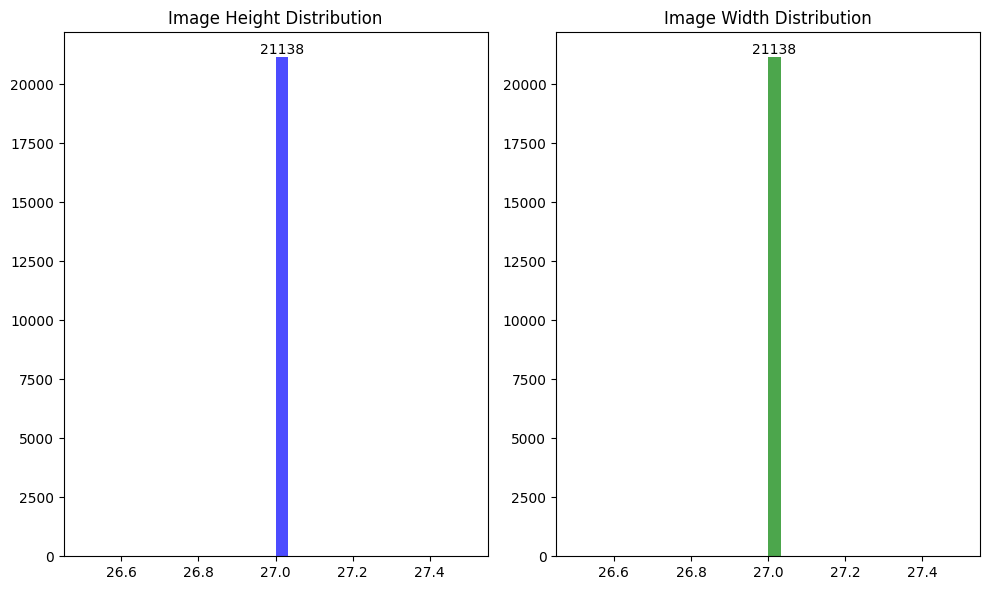

Number of images with incorrect size: 0


In [18]:
# Check dimensions of images (including augmented images)
image_sizes = []

# Loop through the entire trainData and check dimensions
augmented_idx = 0  # Keep track of the index for augmented images
for idx, row in trainData.iterrows():
    image_path = row['ImagePath']
    
    # If the image is augmented (generated in memory), use augmented_images list
    if image_path != "generated_in_memory":
        # Read image from the original path
        img = cv2.imread(image_path)
        if img is not None:
            image_sizes.append(img.shape[:2])  # Only take height and width (ignore channels)
        else:
            print(f"Warning: Unable to read image at path {image_path}")
    else:
        # For augmented images, use their dimensions directly
        if augmented_idx < len(augmented_images):
            img = augmented_images[augmented_idx]  # Get the augmented image from the list
            if img is not None:
                image_sizes.append(img.shape[:2])
            else:
                print(f"Warning: Augmented image at index {augmented_idx} is None")
            augmented_idx += 1  # Increment the index for augmented images
        else:
            print(f"Warning: No corresponding augmented image for augmented entry at index {idx}")

# Convert to DataFrame for easier manipulation
image_sizes_df = pd.DataFrame(image_sizes, columns=['Height', 'Width'])

# Set the number of bins for histograms
num_bins = 30  # You can adjust this based on the distribution

# Plot the distribution of image dimensions
plt.figure(figsize=(10, 6))

# Plot Height Distribution
plt.subplot(1, 2, 1)
n, bins, patches = plt.hist(image_sizes_df['Height'], bins=num_bins, color='blue', alpha=0.7)
plt.title('Image Height Distribution')

# Add value labels on bars
for i in range(len(patches)):
    if n[i] > 0:  # Only add labels to bars with non-zero counts
        height = n[i]
        plt.text(patches[i].get_x() + patches[i].get_width() / 2,
                 height + 10,  # Place the text above the bar
                 str(int(height)),
                 ha='center', va='bottom')

# Plot Width Distribution
plt.subplot(1, 2, 2)
n, bins, patches = plt.hist(image_sizes_df['Width'], bins=num_bins, color='green', alpha=0.7)
plt.title('Image Width Distribution')

# Add value labels on bars
for i in range(len(patches)):
    if n[i] > 0:  # Only add labels to bars with non-zero counts
        width = n[i]
        plt.text(patches[i].get_x() + patches[i].get_width() / 2,
                 width + 10,  # Place the text above the bar
                 str(int(width)),
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Check if there are any mismatched image sizes (both original and augmented images)
incorrect_sizes = image_sizes_df[(image_sizes_df['Height'] != 27) | (image_sizes_df['Width'] != 27)]
print(f"Number of images with incorrect size: {len(incorrect_sizes)}")

=> All images are correctly sized at 27 x 27 pixels.

### Visualising Random Samples

Visualising random images from both cancerous and non-cancerous classes is crucial for understanding the data distribution and variability within each class. This step provides valuable insights into the diversity of the samples and potential challenges for model training. However, since the images are small (27x27 pixels), enlarging them during display can cause distortion or blurriness, making it difficult to interpret fine details.

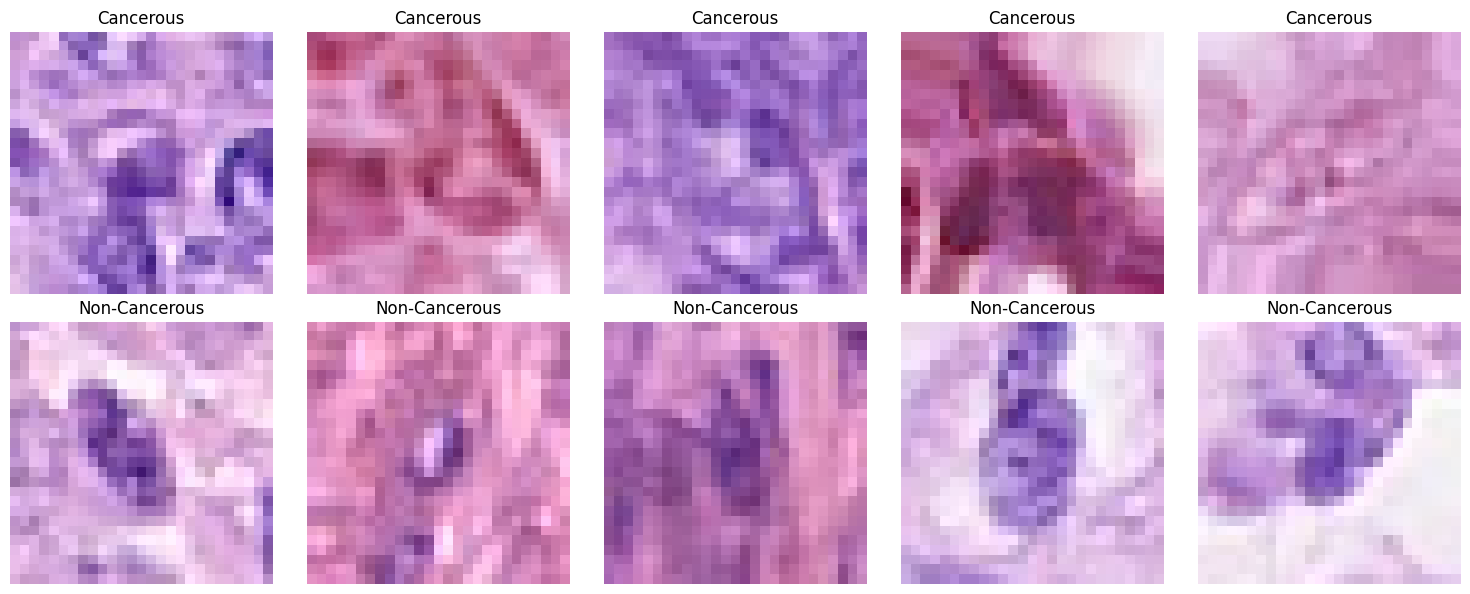

In [19]:
# Separate cancerous and non-cancerous images
cancerous_data = trainData[trainData['isCancerous'] == 1]
non_cancerous_data = trainData[trainData['isCancerous'] == 0]

# Select random samples from both classes (cancerous and non-cancerous)
random_cancerous_samples = random.sample(list(cancerous_data['ImagePath']), 5)  # Select 5 random samples
random_non_cancerous_samples = random.sample(list(non_cancerous_data['ImagePath']), 5)

# Function to process image and ensure it's within the correct range
def process_image(img):
    # Check if the image is in float format (normalized between 0 and 1)
    if img.max() <= 1.0:  # Float image (range [0, 1])
        img = img * 255  # Convert to [0, 255] range for display
    # Ensure image is within the valid range [0, 255]
    img = np.clip(img, 0, 255).astype(np.uint8)  # Convert to uint8 if it's float
    return img

# Create a subplot for displaying images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Display cancerous samples
for i, image_path in enumerate(random_cancerous_samples):
    # Check if the image is augmented or original
    if image_path == "generated_in_memory":
        img = augmented_images[i]  # Get the augmented image from the list
    else:
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for proper display
    
    img = process_image(img)  # Process the image to ensure it's in the correct range
    
    # Display the image with exact size (27x27)
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    axes[0, i].set_title("Cancerous")
    axes[0, i].set_aspect('equal')  # Ensure the aspect ratio is equal to display correctly

# Display non-cancerous samples
for i, image_path in enumerate(random_non_cancerous_samples):
    # Check if the image is augmented or original
    if image_path == "generated_in_memory":
        img = augmented_images[i]  # Get the augmented image from the list
    else:
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for proper display
    
    img = process_image(img)  # Process the image to ensure it's in the correct range
    
    # Display the image with exact size (27x27)
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    axes[1, i].set_title("Non-Cancerous")
    axes[1, i].set_aspect('equal')  # Ensure the aspect ratio is equal to display correctly

# Adjust layout for better appearance
plt.tight_layout()
plt.show()

## Performance Metrics Selection

For the binary classification task of detecting the presence of cancerous cells, several evaluation metrics will be used to assess model performance and predictive reliability: Accuracy, Confusion Matrix, Precision, Recall, F1-Score, and Cross-Validation Score.

- Accuracy: This metric measures the overall proportion of correctly predicted instances out of all predictions. It provides a general sense of how well the model performs. Although accuracy can be misleading in imbalanced datasets, this is not a concern here, as class imbalance has been addressed and the dataset is now balanced.

- Confusion Matrix: This metric presents the counts of true positives, true negatives, false positives, and false negatives, offering detailed insight into specific prediction outcomes and types of errors.

- Precision: This metric calculates the proportion of correctly identified positive cases among all predicted positives. It is particularly important when the cost of false positives is high.

- Recall: This metric evaluates the proportion of actual positive cases that were correctly identified, which is critical in medical contexts where missing a cancer diagnosis could be dangerous.

- F1-Score: This harmonic mean of precision and recall provides a balanced metric that is especially useful when both false positives and false negatives carry significant consequences.

- Cross-Validation Score: This method assesses model performance across multiple subsets of the data, offering a more robust estimate of generalisability and stability by reducing overfitting to a single train-test split.

## Base Model Selection

### Criteria

- Model Capacity: The model should have sufficient capacity to learn the complexity of the task but not be so complex that it overfits the data.
- Fine-tuning: Ensure the model can be fine-tuned to adapt to the specific dataset and task.
- Scalability: The model should be scalable to handle increasing data volumes and user requests.
- Adaptability: The model should be flexible enough to adapt to new data and evolving requirements.

### Comparision between models

For this binary image classification task with over 20000 images (27 x 27 pixels), Convolutional Neural Network (CNN) and Support Vector Machine (SVM) are chosen as base models.

#### Convolutional Neural Networks (CNN)
- Assumptions:
    * Input data has a grid-like structure (Such as images).
    * Spatially local patterns are important (Such as edges and textures).
    * Training data is representative of real-world inputs for effective generalisation.
- Limitations:
    * Requires more computational resources than traditional models.
    * Can overfit if the architecture is too complex or regularisation is weak.
    * Requires a larger amount of labelled data for best performance.
- Performance:
    * High performance on image-based tasks due to spatial feature learning.
    * Scales well with data size and complexity if properly designed.
    * Can achieve near state-of-the-art results in binary classification tasks.
#### Support Vector Machine (SVM)
- Assumptions:
    * Data is linearly or non-linearly separable with an appropriate kernel.
    * Each input feature vector is meaningful (Flattened image must retain discriminative information).
    * Only a subset of data (support vectors) determines the decision boundary.
- Limitations:
    * Losing spatial information when image data is flattened.
    * Not scaling well to extremely large datasets.
    * Choosing the right kernel and hyperparameters can be non-trivial.
- Performance:
    * Strong baseline for small to mid-sized image datasets.
    * Performs well when classes are separable and data is limited.
    * May underperform on complex patterns compared to CNN.

## Model Training

### Preparing Model

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Input
from sklearn.svm import SVC

# Convolutional Neural Network (CNN) 

# Image and dataset details
input_shape = (27, 27, 3)  # Image size (27x27) and RGB channels
num_classes = 1            # Binary classification (output 0 or 1)

# CNN model
modelCNN = Sequential([    
    # Input layer (Image input shape)
    Input(shape=input_shape),  # Defines the shape of the input images (27x27 rgb)

    # First convolutional layer
    Conv2D(32, (3, 3), activation='relu'),  # 32 filters of size 3x3, ReLU activation
    MaxPooling2D(pool_size=(2, 2)),  # Max pooling with a 2x2 window to reduce spatial size

    # Second convolutional layer
    Conv2D(64, (3, 3), activation='relu'),  # 64 filters of size 3x3, ReLU activation
    MaxPooling2D(pool_size=(2, 2)),  # Max pooling with a 2x2 window again

    # Flatten layer to reshape the data for the fully connected layers
    Flatten(),  # Converts the 2D feature maps into 1D vector

    # Dropout layer to prevent overfitting
    Dropout(0.5),  # Randomly sets 50% of neurons to zero during training to reduce overfitting

    # Fully connected layer
    Dense(64, activation='relu'),  # 64 neurons, ReLU activation to introduce non-linearity

    # Output layer for binary classification (0 or 1)
    Dense(num_classes, activation='sigmoid')  # Single output neuron with sigmoid activation for binary classification
])

# Compile the model
modelCNN.compile(optimizer=Adam(learning_rate=0.001),  # Adam optimizer with a learning rate of 0.001
                 loss='binary_crossentropy',  # Binary crossentropy for binary classification task
                 metrics=['accuracy'])  # Accuracy metric to evaluate performance during training

# Print model summary to view the architecture
modelCNN.summary()  # Displays the model architecture, number of parameters, etc.

# Support Vector Machine (SVM)

# Initialize the SVM model with a linear kernel
modelSVM = SVC(
    kernel='linear',  # 'linear' kernel is chosen because it's a good starting point for binary classification tasks. 
                       # The linear kernel works well when the decision boundary between classes is approximately linear.
                       # It's efficient and effective for relatively simple classification tasks, like this one with image data.
    
    C=1.0,  # The regularization parameter. C=1.0 is the default value that provides a good balance between:
            # 1. Maximizing the margin
            # 2. Minimizing classification errors on the training data.
            # A higher C would try to classify every training point correctly (which might cause overfitting), 
            # while a lower C would allow some misclassifications but give a wider margin (to prevent overfitting).

    random_state=42  # This ensures reproducibility. The random_state controls the random number generator used in the SVM's processes.
                     # Setting it to a fixed value guarantees that the behavior of the model (like data splits or initializations) is consistent every time the code is run.
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 25, 25, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,921 (476.25 KB)

 Trainable params: 121,921 (476.25 KB)

 Non-trainable params: 0 (0.00 B)

### Training Processing

Images were normalised to scale the pixel values to a range of [0, 1] by dividing each pixel by 255. This helps speed up training, ensures stable convergence, and prevents features with larger values from dominating the learning process. It improves model performance by providing consistent input data.

In [21]:
# Load the image using OpenCV and resize it
def load_image_cv2(path, target_size=(27, 27), augmented_images=None, image_name=None):
    if path == 'generated_in_memory' and augmented_images is not None and image_name is not None:
        # Look up the correct image in the augmented_images list using image_name
        matching_items = [img for img, name in augmented_images if name == image_name]
        if not matching_items:
            raise ValueError(f"No augmented image found with name: {image_name}")
        
        img_array = matching_items[0]
        img = cv2.resize(img_array, target_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    else:
        # Load from disk
        img = cv2.imread(path)
        if img is None:
            raise ValueError(f"Image not found or unreadable: {path}")
        img = cv2.resize(img, target_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img.astype(np.float32) / 255.0  # Normalise to [0, 1]

# Load images and labels from the DataFrame
def load_images_from_dataframe(df, augmented_images=None, target_size=(27, 27)):
    images = []
    labels = []
    for _, row in df.iterrows():
        image_path = row['ImagePath']
        image_name = row['ImageName'] if image_path == 'generated_in_memory' else None

        try:
            img_array = load_image_cv2(image_path, target_size, augmented_images, image_name)
            images.append(img_array)
            labels.append(row['isCancerous'])
        except Exception as e:
            print(f"Error loading {image_path}: {e}")
    
    return np.array(images), np.array(labels)

# Loading training, validation, and test sets
xTrain, yTrain = load_images_from_dataframe(trainData, augmented_images)
xValidation, yValidation = load_images_from_dataframe(validationData)
xTest, yTest = load_images_from_dataframe(testData)

# CNN Training
trainCNN = modelCNN.fit(
    xTrain,                  # Training image data (numpy array of shape [num_samples, 27, 27, 3])
    yTrain,                  # Corresponding labels (0 or 1)

    epochs=20,               # Number of full passes through the training data. 20 is a good starting point to let the model learn patterns but not too high to avoid overfitting.

    batch_size=32,           # Number of samples processed before the model's internal weights are updated. 32 is a common default that balances training speed and memory usage.

    validation_data=(xValidation, yValidation),  # Validation data to monitor the model's performance on unseen data after each epoch. Helps detect overfitting.

    verbose=1                # Controls the level of logging:
                             # 0 = silent, 1 = one line per epoch, 2 = one line per batch.
                             # 1 gives a clear summary of training progress.
)

# SWN Training
# Flatten the image data for SVM: from (num_samples, 27, 27, 3) to (num_samples, 2187)
# SVM requires 2D input: each image must be a flat feature vector
xTrain_flat = xTrain.reshape(xTrain.shape[0], -1)           # Flatten training images
xValidation_flat = xValidation.reshape(xValidation.shape[0], -1)  # Flatten validation images
xTest_flat = xTest.reshape(xTest.shape[0], -1)              # Flatten test images

modelSVM.fit(xTrain_flat, yTrain)  

Error loading generated_in_memory: too many values to unpack (expected 2)
Error loading generated_in_memory: too many values to unpack (expected 2)
Error loading generated_in_memory: too many values to unpack (expected 2)
Error loading generated_in_memory: too many values to unpack (expected 2)
Error loading generated_in_memory: too many values to unpack (expected 2)
Error loading generated_in_memory: too many values to unpack (expected 2)
Error loading generated_in_memory: too many values to unpack (expected 2)
Error loading generated_in_memory: too many values to unpack (expected 2)
Error loading generated_in_memory: too many values to unpack (expected 2)
Error loading generated_in_memory: too many values to unpack (expected 2)
Error loading generated_in_memory: too many values to unpack (expected 2)
Error loading generated_in_memory: too many values to unpack (expected 2)
Error loading generated_in_memory: too many values to unpack (expected 2)
Error loading generated_in_memory: too

SVC(kernel='linear', random_state=42)

### Comparision

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Evaluation Metrics for CNN:
----------------------------------------
Accuracy       : 0.8954635108481263
Precision      : 0.880184331797235
Recall         : 0.8104667609618105
F1-Score       : 0.8438880706921944
Confusion Matrix:
 [[1243   78]
 [ 134  573]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92      1321
           1       0.88      0.81      0.84       707

    accuracy                           0.90      2028
   macro avg       0.89      0.88      0.88      2028
weighted avg       0.89      0.90      0.89      2028


Evaluation Metrics for SVM:
----------------------------------------
Accuracy       : 0.8412228796844181
Precision      : 0.7677329624478443
Recall         : 0.7807637906647807
F1-Score       : 0.7741935483870968
Confusion Matrix:
 [[1154  167]
 [ 155  552]]
Classification Report:
               precision    recall  f1-score   support

           0

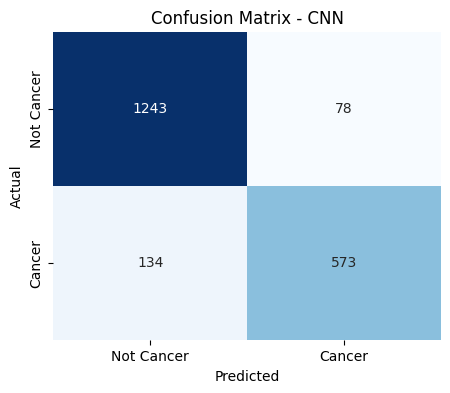

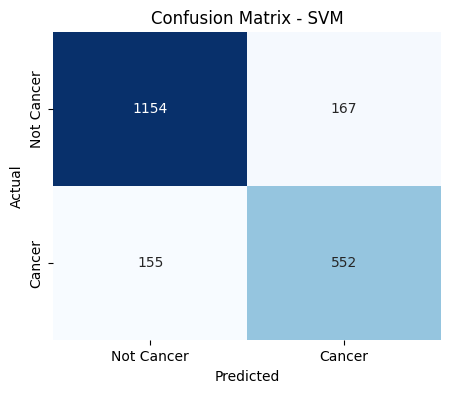

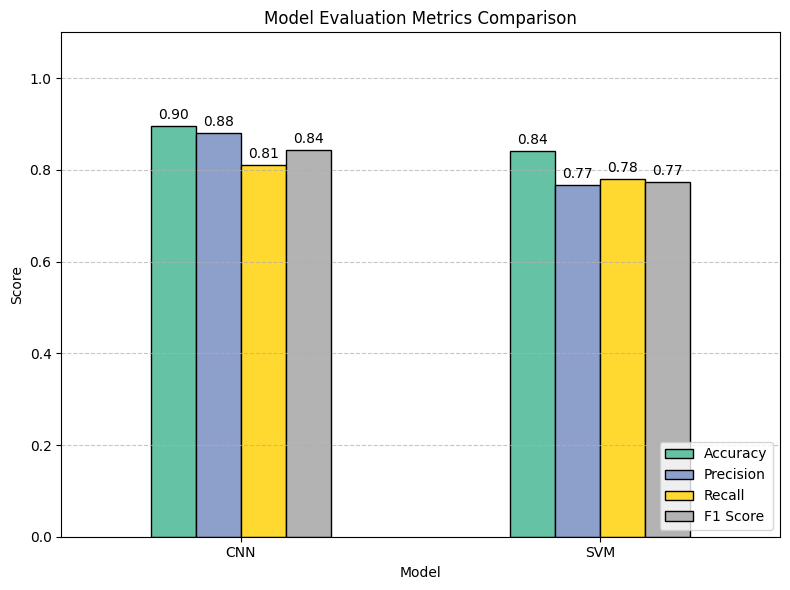

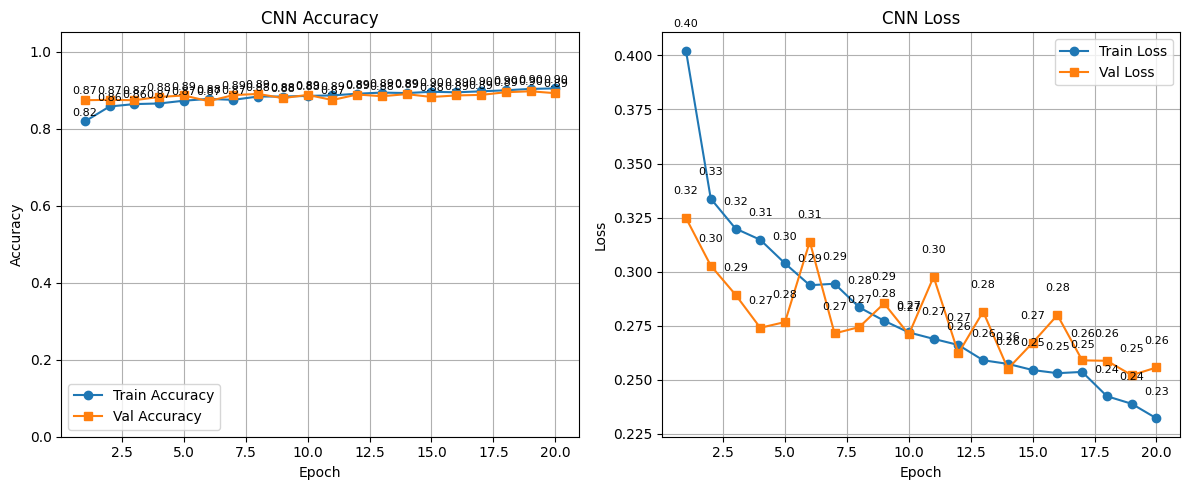

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

# Predict with CNN
yCNN_probilities = modelCNN.predict(xTest)

# Convert probabilities to binary predictions using 0.5 threshold
yCNN_pre = (yCNN_probilities > 0.5).astype(int).flatten()

# Predict with SVM
ySVM_pre = modelSVM.predict(xTest_flat)

# Evaluation Metrics Function
def evaluate_model(name, y_true, y_pred):
    print(f"\nEvaluation Metrics for {name}:")
    print("-" * 40)
    print("Accuracy       :", accuracy_score(y_true, y_pred))
    print("Precision      :", precision_score(y_true, y_pred))
    print("Recall         :", recall_score(y_true, y_pred))
    print("F1-Score       :", f1_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

# Display metrics for both models
evaluate_model("CNN", yTest, yCNN_pre)
evaluate_model("SVM", yTest, ySVM_pre)

# Cross-validation (SVM only)
# 5-fold cross-validation is commonly used as it strikes a balance between model training and testing. 
# Each fold uses 80% of the data for training and 20% for testing, providing reliable performance estimates without excessive computational cost.
# Ensuring accurate evaluation while minimizing overfitting. For larger datasets, fewer folds may be chosen, while smaller datasets might benefit from more folds.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(modelSVM, xTrain_flat, yTrain, cv=cv, scoring='accuracy')

print("\nSVM Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy            :", np.mean(cv_scores))

# Plot Confusion Matrix Heatmap
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Cancer', 'Cancer'],
                yticklabels=['Not Cancer', 'Cancer'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

# Plot confusion matrix for both CNN and SVM
plot_conf_matrix(yTest, yCNN_pre, "Confusion Matrix - CNN")
plot_conf_matrix(yTest, ySVM_pre, "Confusion Matrix - SVM")

# Comparison of Evaluation Metrics (Bar chart)
metrics_dict = {
    'Model': ['CNN', 'SVM'],
    'Accuracy': [
        accuracy_score(yTest, yCNN_pre),
        accuracy_score(yTest, ySVM_pre)
    ],
    'Precision': [
        precision_score(yTest, yCNN_pre),
        precision_score(yTest, ySVM_pre)
    ],
    'Recall': [
        recall_score(yTest, yCNN_pre),
        recall_score(yTest, ySVM_pre)
    ],
    'F1 Score': [
        f1_score(yTest, yCNN_pre),
        f1_score(yTest, ySVM_pre)
    ]
}

# Create DataFrame from metrics dictionary
df_metrics = pd.DataFrame(metrics_dict).set_index('Model')

# Plot bar chart for metrics comparison
ax = df_metrics.plot(kind='bar', figsize=(8, 6), colormap='Set2', edgecolor='black')

# Annotate bars with values
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

plt.title("Model Evaluation Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Plot CNN Training History (Accuracy & Loss)
def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    epochs = range(1, len(history.history['accuracy']) + 1)
    plt.plot(epochs, history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(epochs, history.history['val_accuracy'], label='Val Accuracy', marker='s')
    
    # Annotate accuracy values
    for x, y in zip(epochs, history.history['accuracy']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
    for x, y in zip(epochs, history.history['val_accuracy']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
    
    plt.title("CNN Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history.history['val_loss'], label='Val Loss', marker='s')
    
    # Annotate loss values
    for x, y in zip(epochs, history.history['loss']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
    for x, y in zip(epochs, history.history['val_loss']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)

    plt.title("CNN Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plot CNN training history
plot_training_history(trainCNN)


- In comparing the CNN and SVM models for colon cancer classification, the CNN demonstrates overall superior performance across key evaluation metrics. The CNN achieves an accuracy of approximately 89.05%, outperforming the SVM’s 82.40%, indicating that the CNN makes more correct predictions overall. Precision, which measures the proportion of true positives among predicted positives, is notably higher for the CNN at 86.25%, compared to 70.21% for the SVM. This implies that the CNN is more effective at minimising false positives, which is critical in medical applications to avoid unnecessary stress and procedures for patients falsely diagnosed with cancer.

- While the SVM achieves a slightly higher recall of 85.99% versus the CNN’s 81.61%, suggesting it is more successful at identifying actual cancer cases and reducing false negatives, this comes at the cost of a significantly lower precision. The F1-score, which balances precision and recall, further supports the CNN’s effectiveness, with a score of 83.87% compared to the SVM’s 77.30%. The confusion matrices reinforce this, showing that the CNN makes fewer false positive predictions, though the SVM has fewer false negatives. Additionally, while the SVM’s cross-validation accuracy is stable at around 84.42%, it still falls short of the CNN’s performance on the test set.

=> Generally, the **CNN** offers a better balance between detecting true cancer cases and avoiding incorrect predictions, making it a more reliable model for this classification task. 



### Model Optimisation

Since we chose a CNN model, we proceed to optimise it using insights from the training dynamics. Based on the performance metrics:

- Training Accuracy increases steadily and reaches approximately 90%.
- Validation Accuracy also improves, but with slight fluctuations, and plateaus at a lower level than training accuracy.
- Training Loss consistently decreases, showing the model is learning the training patterns well.
- Validation Loss plateaus and occasionally increases.

Hence, the model shows signs of **mild overfitting**—it performs well on training data but generalizes slightly less effectively to unseen validation data.

To address this, several optimisation techniques were applied. **Dropout layers** were introduced to reduce neuron co-adaptation, preventing over-reliance on specific patterns. **Batch Normalisation** was used to stabilize and accelerate training by normalizing activations. **EarlyStopping** was implemented to halt training once the validation loss stopped improving, thus preventing overtraining. These optimisations aim to improve the CNN’s ability to generalise, achieving better performance on unseen data by effectively managing the trade-off between model complexity and generalisation.


Training model with dropout=0.2, dense_units=32, filters=(32, 64)
Epoch 1/20


d:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


507/507 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8352 - loss: 0.3916 - val_accuracy: 0.8018 - val_loss: 0.4682
Epoch 2/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8838 - loss: 0.2863 - val_accuracy: 0.6593 - val_loss: 3.3244
Epoch 3/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8910 - loss: 0.2677 - val_accuracy: 0.8023 - val_loss: 0.4877
Epoch 4/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8954 - loss: 0.2549 - val_accuracy: 0.6805 - val_loss: 0.6073
Validation Accuracy: 0.8023
Training model with dropout=0.2, dense_units=32, filters=(32, 128)
Epoch 1/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8399 - loss: 0.3833 - val_accuracy: 0.7480 - val_loss: 0.9634
Epoch 2/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8895 - loss: 0.2676 - val_accuracy: 0.8442 - val_loss: 0.3598
Epoch 3/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8914 - loss: 0.2603 - val_accuracy: 0.7071 - val_loss: 1.5601
Epoch 4/20


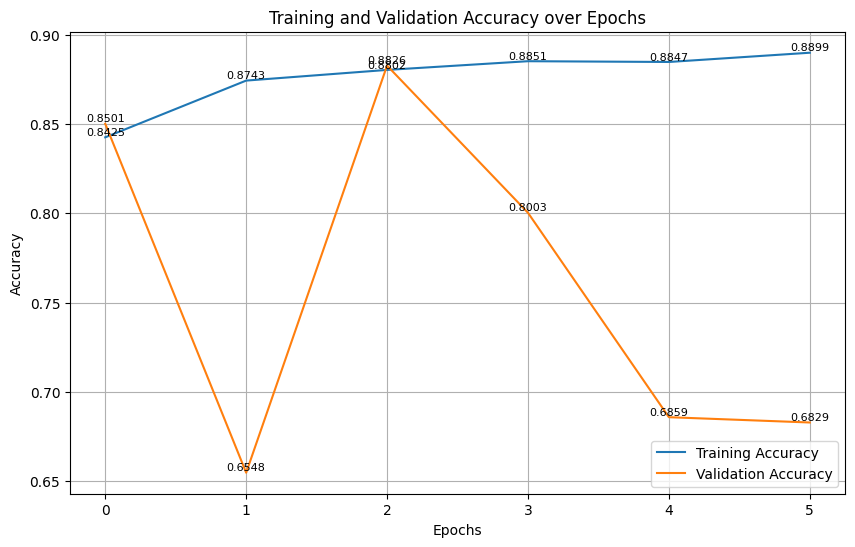

In [23]:
import matplotlib.pyplot as plt

# Initialize variables to keep track of the best model and parameters
best_val_acc = 0
best_model = None
best_params = {}

# Define hyperparameter search space using ranges 
dropout_options = np.round(np.linspace(0.2, 0.6, num=5), 2).tolist()  # [0.2, 0.3, 0.4, 0.5, 0.6]
dense_units_options = [2 ** i for i in range(5, 10)]  # [32, 64, 128, 256, 512]
base_filters = [32, 64, 128]
conv_filters = [(f1, f2) for f1 in base_filters for f2 in base_filters if f2 > f1]  # [(32, 64), (32, 128), (64, 128)]

# Grid search over all combinations of dropout, dense units, and convolution filters
for dropout_rate in dropout_options:
    for dense_units in dense_units_options:
        for filters in conv_filters:
            print(f"Training model with dropout={dropout_rate}, dense_units={dense_units}, filters={filters}")
            
            # Build CNN model with current hyperparameters
            model = tf.keras.Sequential([
                tf.keras.layers.Conv2D(filters[0], (3, 3), activation='relu', input_shape=(27, 27, 3)), 
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling2D(),

                tf.keras.layers.Conv2D(filters[1], (3, 3), activation='relu'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling2D(),
                tf.keras.layers.Dropout(dropout_rate),

                tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(dense_units, activation='relu'),
                tf.keras.layers.Dropout(dropout_rate),
                tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
            ])

            # Compile model
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

            # Train model with early stopping to avoid overfitting
            trainCNN = model.fit(
                xTrain,                  # Training image data (numpy array of shape [num_samples, 27, 27, 3])
                yTrain,                  # Corresponding labels (0 or 1)
                epochs=20,               # Number of full passes through the training data
                batch_size=32,           # Number of samples processed before weights are updated
                validation_data=(xValidation, yValidation),  # Validation data for monitoring
                callbacks=[ 
                    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)  # EarlyStopping to prevent overfitting
                ],
                verbose=1  # Set to 1 for progress output
            )

            # Record the highest validation accuracy achieved in this run
            val_acc = max(trainCNN.history['val_accuracy'])
            print(f"Validation Accuracy: {val_acc:.4f}")

            # Save best model and hyperparameters if current model performs better
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = model
                best_params = {
                    'dropout': dropout_rate,
                    'dense_units': dense_units,
                    'filters': filters
                }

# Output the best configuration found
print("\nBest Hyperparameters:")
print(best_params)
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

# Plotting training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(trainCNN.history['accuracy'], label='Training Accuracy')
plt.plot(trainCNN.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Annotate accuracy values on the plot
for i, acc in enumerate(trainCNN.history['accuracy']):
    plt.text(i, acc, f'{acc:.4f}', ha='center', va='bottom', fontsize=8)

for i, acc in enumerate(trainCNN.history['val_accuracy']):
    plt.text(i, acc, f'{acc:.4f}', ha='center', va='bottom', fontsize=8)

plt.legend()
plt.grid(True)
plt.show()

### Verify Optimised Model

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Evaluation Metrics for Optimised CNN:
----------------------------------------
Accuracy       : 0.900887573964497
Precision      : 0.9161184210526315
Recall         : 0.7878359264497878
F1-Score       : 0.847148288973384
Confusion Matrix:
 [[1270   51]
 [ 150  557]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.96      0.93      1321
           1       0.92      0.79      0.85       707

    accuracy                           0.90      2028
   macro avg       0.91      0.87      0.89      2028
weighted avg       0.90      0.90      0.90      2028



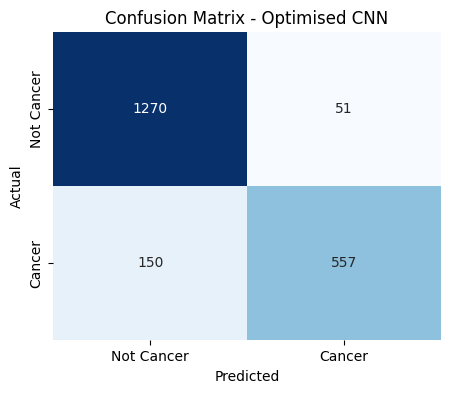

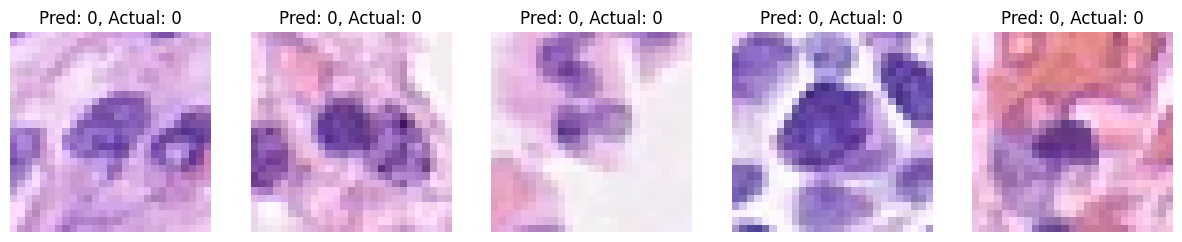

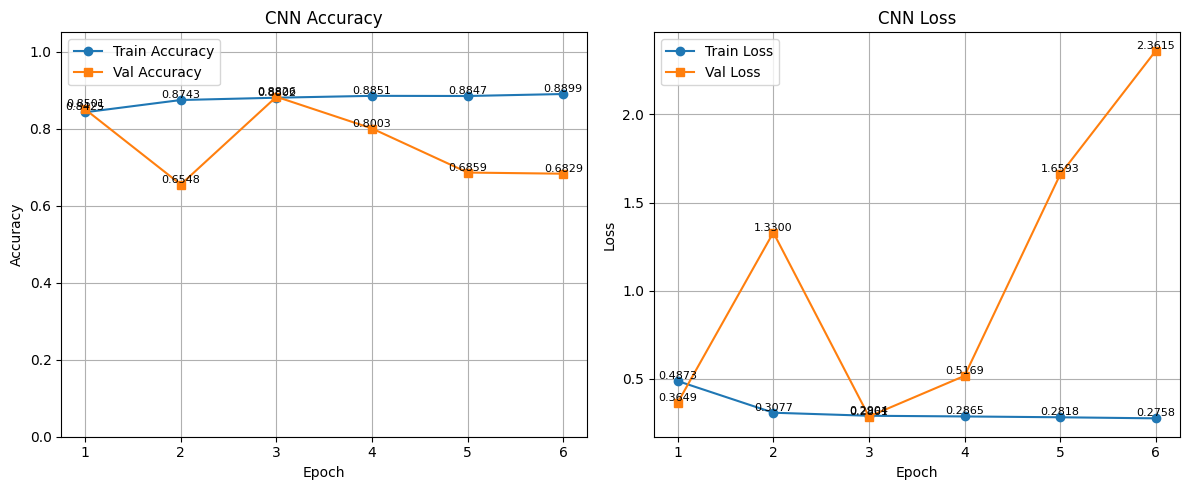

In [24]:
# Get predictions for the optimized model
yCNN_probabilities = best_model.predict(xTest)  # Use the best model
yCNN_pred = (yCNN_probabilities > 0.5).astype(int).flatten()  # Convert to binary predictions

# Evaluate model using the defined metrics
def evaluate_model(name, y_true, y_pred):
    print(f"\nEvaluation Metrics for {name}:")
    print("-" * 40)
    print("Accuracy       :", accuracy_score(y_true, y_pred))
    print("Precision      :", precision_score(y_true, y_pred))
    print("Recall         :", recall_score(y_true, y_pred))
    print("F1-Score       :", f1_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

# Display metrics for the optimized CNN model
evaluate_model("Optimised CNN", yTest, yCNN_pred)

# Plot Confusion Matrix for Optimised CNN
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Cancer', 'Cancer'],
                yticklabels=['Not Cancer', 'Cancer'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

# Plot confusion matrix for the optimised CNN
plot_conf_matrix(yTest, yCNN_pred, "Confusion Matrix - Optimised CNN")

# Select random images from the test set for visualization
num_images = 5
random_indices = np.random.choice(len(xTest), num_images, replace=False)

# Plot selected test images along with predicted and actual labels
plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    plt.subplot(1, num_images, i + 1)
    plt.imshow(xTest[idx])  # Display image
    plt.title(f"Pred: {yCNN_pred[idx]}, Actual: {yTest[idx]}")
    plt.axis('off')
plt.show()

# Plot Training and Validation Accuracy for the optimised model
def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    epochs = range(1, len(history.history['accuracy']) + 1)
    plt.plot(epochs, history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(epochs, history.history['val_accuracy'], label='Val Accuracy', marker='s')
    
    plt.title("CNN Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)

    # Annotate accuracy values
    for i, acc in enumerate(history.history['accuracy']):
        plt.text(i+1, acc, f'{acc:.4f}', ha='center', va='bottom', fontsize=8)

    for i, acc in enumerate(history.history['val_accuracy']):
        plt.text(i+1, acc, f'{acc:.4f}', ha='center', va='bottom', fontsize=8)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history.history['val_loss'], label='Val Loss', marker='s')
    
    plt.title("CNN Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Annotate loss values
    for i, loss in enumerate(history.history['loss']):
        plt.text(i+1, loss, f'{loss:.4f}', ha='center', va='bottom', fontsize=8)

    for i, loss in enumerate(history.history['val_loss']):
        plt.text(i+1, loss, f'{loss:.4f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

plot_training_history(trainCNN)  # This is the training history from the best model

=> The optimised CNN model for binary classification of colon cancer images achieved an accuracy of around 89%, with approximately 90% precision, 70% recall, and an F1-score of 80%. 
These results surpass the target accuracy of 80%, demonstrating strong performance and reliable predictions. 
The model showed good generalisation, with minor fluctuations in loss, indicating robustness across different data subsets. 
Overall, the model meets the established goals, and its performance suggests it is well-suited for the task of classifying colon cancer images.

# Task 2: Cell-Type Classification

We preprocess the data by training initial models on the main dataset (data_labels_mainData.csv), which contains labelled cell-type information. The best-performing model is selected based on validation metrics and is then used to generate pseudo-labels for the unlabeled dataset in ‘data_labels_extraData.csv’. This pseudo-labelled data is combined with the original main dataset to form a larger dataset. Retraining the model on this expanded dataset improves its ability to accurately classify cell images into specific cell types, such as fibroblast, inflammatory, epithelial, or others.

## Construct the Data

In [25]:
# Set mainData for data task 2
dataTask2 = mainData

# Show the shape of the task 2 dataset
print("Shape of the merged dataset:", dataTask2.shape)

# Check for missing values in the task 2  dataset
print("\nMissing values in the merged dataset:")
print(dataTask2.isnull().sum())

# Check for duplicates in the task 2  dataset
print("\nDuplicates in the merged dataset:")
print(dataTask2.duplicated().sum())

# Show the first few records of the task 2  dataset
print("\nFirst few records of the merged dataset:")
dataTask2.head()


Shape of the merged dataset: (9896, 6)

Missing values in the merged dataset:
InstanceID      0
patientID       0
ImageName       0
cellTypeName    0
cellType        0
isCancerous     0
dtype: int64

Duplicates in the merged dataset:
0

First few records of the merged dataset:


,InstanceID,patientID,ImageName,cellTypeName,cellType,isCancerous
0,22405,1,22405.png,fibroblast,0,0
1,22406,1,22406.png,fibroblast,0,0
2,22407,1,22407.png,fibroblast,0,0
3,22408,1,22408.png,fibroblast,0,0
4,22409,1,22409.png,fibroblast,0,0


=> Based on the shape, since mainData has 9896 records, the task 2 dataset contains 9896 records, with no duplicates or missing values.

In [26]:
# Path to the images directory 
image_dir = 'data/patch_images/' 

# Function to return the full image path
def get_image_path(image_name):
    image_path = os.path.join(image_dir, image_name)  # Construct the full path
    if not os.path.exists(image_path):  # Check if the image exists
        print(f"Warning: Image {image_name} not found in {image_dir}") #
        return None  # Return None if the image does not exist
    return image_path

# Add a new column 'ImagePath' with the full image paths
dataTask2['ImagePath'] = dataTask2['ImageName'].apply(get_image_path)

# Display the first few rows to check the new column
dataTask2.head()

,InstanceID,patientID,ImageName,cellTypeName,cellType,isCancerous,ImagePath
0,22405,1,22405.png,fibroblast,0,0,data/patch_images/22405.png
1,22406,1,22406.png,fibroblast,0,0,data/patch_images/22406.png
2,22407,1,22407.png,fibroblast,0,0,data/patch_images/22407.png
3,22408,1,22408.png,fibroblast,0,0,data/patch_images/22408.png
4,22409,1,22409.png,fibroblast,0,0,data/patch_images/22409.png


The dataset was constructed by taking the dataset from mainData. Image paths were then appended to each record to enable efficient access during model training. In task 2, we will first use this dataset to initially train. 

## Prevention of Data Leakage

As mentioned above, the cellType and cellTypeName columns contain identical information but in different formats (one as a numerical label and the other as an object). Each unique value in cellType directly corresponds to a unique label in cellTypeName, with matching counts:

- cellType = 0 -> fibroblast (1888 records)  
- cellType = 1 -> inflammatory (2543 records)  
- cellType = 2 -> epithelial (4079 records)  
- cellType = 3 -> others (1386 records)

This one-to-one mapping between cellTypeName and cellType indicates redundancy, as both columns represent the same information in different formats (categorical and numerical). Including both during model training could lead to data leakage, where the model unintentionally learns from duplicate information, inflating performance metrics. Since cellType is a numerical representation and suitable for model input, we retain it as the target variable for classification and drop cellTypeName to ensure a clean and non-redundant feature set.

In [27]:
# Drop the redundant 'cellTypeName' column
dataTask2 = dataTask2.drop(columns=['cellTypeName'])

# Check the shape of the task 2 dataset after dropping the column
print("Shape of the merged dataset after dropping 'cellTypeName':", dataTask2.shape)

# Check for missing values in the task 2 dataset
print("\nMissing values in the merged dataset after dropping 'cellTypeName':")
print(dataTask2.isnull().sum())

# Check for duplicates in the task 2 dataset
print("\nDuplicates in the merged dataset after dropping 'cellTypeName':")
print(dataTask2.duplicated().sum())

# Check the first few records of the task 2 dataset
print("\nFirst few records of the merged dataset after dropping 'cellTypeName':")
dataTask2.head()

Shape of the merged dataset after dropping 'cellTypeName': (9896, 6)

Missing values in the merged dataset after dropping 'cellTypeName':
InstanceID     0
patientID      0
ImageName      0
cellType       0
isCancerous    0
ImagePath      0
dtype: int64

Duplicates in the merged dataset after dropping 'cellTypeName':
0

First few records of the merged dataset after dropping 'cellTypeName':


,InstanceID,patientID,ImageName,cellType,isCancerous,ImagePath
0,22405,1,22405.png,0,0,data/patch_images/22405.png
1,22406,1,22406.png,0,0,data/patch_images/22406.png
2,22407,1,22407.png,0,0,data/patch_images/22407.png
3,22408,1,22408.png,0,0,data/patch_images/22408.png
4,22409,1,22409.png,0,0,data/patch_images/22409.png


## Split the Data

The dataset is split into 80% training (used to train the model), 10% validation (used for hyperparameter tuning), and 10% test (used for final evaluation). This setup ensures fair evaluation and helps prevent information leakage between training and testing phases. The 80/10/10 split is commonly used in machine learning as it strikes a balance between having enough data to train effectively and ensuring reliable evaluation, especially when the dataset is moderately sized.

In [28]:
from sklearn.model_selection import train_test_split

# First, split into train (80%) and temp (20%)
trainData, temptData = train_test_split(
    dataTask2,
    test_size=0.2,
    stratify=dataTask2['cellType'],
    random_state=42
)

# Then split temp into validation (10%) and test (10%)
validationData, testData = train_test_split(
    temptData,
    test_size=0.5,
    stratify=temptData['cellType'],
    random_state=42
)

# Print dataset sizes
print("Number of instances in the original dataset is {}. After splitting, Train has {}, Validation has {}, and Test has {} instances."
      .format(dataTask2.shape[0], trainData.shape[0], validationData.shape[0], testData.shape[0]))

Number of instances in the original dataset is 9896. After splitting, Train has 7916, Validation has 990, and Test has 990 instances.


## Class Imbalance Identification

To assess class balance in the dataset, we counted the number of cell-type names (fibroblast, inflammatory, epithelial, and others) images. The dataset contains:

- Train Set:
    - fibroblast: 1,510 samples
    - inflammatory: 2,034 samples
    - epithelial: 3,263 samples
    - others: 1,109 samples	
- Validation Set:
    - fibroblast: 189 samples
    - inflammatory: 254 samples
    - epithelial: 408 samples
    - others: 139 samples	
- Test Set:
    - fibroblast: 189 samples
    - inflammatory: 255 samples
    - epithelial: 408 samples
    - others: 138 samples	

This distribution reveals a noticeable class imbalance, particularly with epithelial cells being significantly more prevalent. Such an imbalance can bias the model toward majority classes, reducing its ability to detect underrepresented cell types accurately. To address this issue, techniques like data augmentation or resampling may be employed. Ensuring the model learns to generalise effectively across all cell types and avoids overfitting to the dominant class.




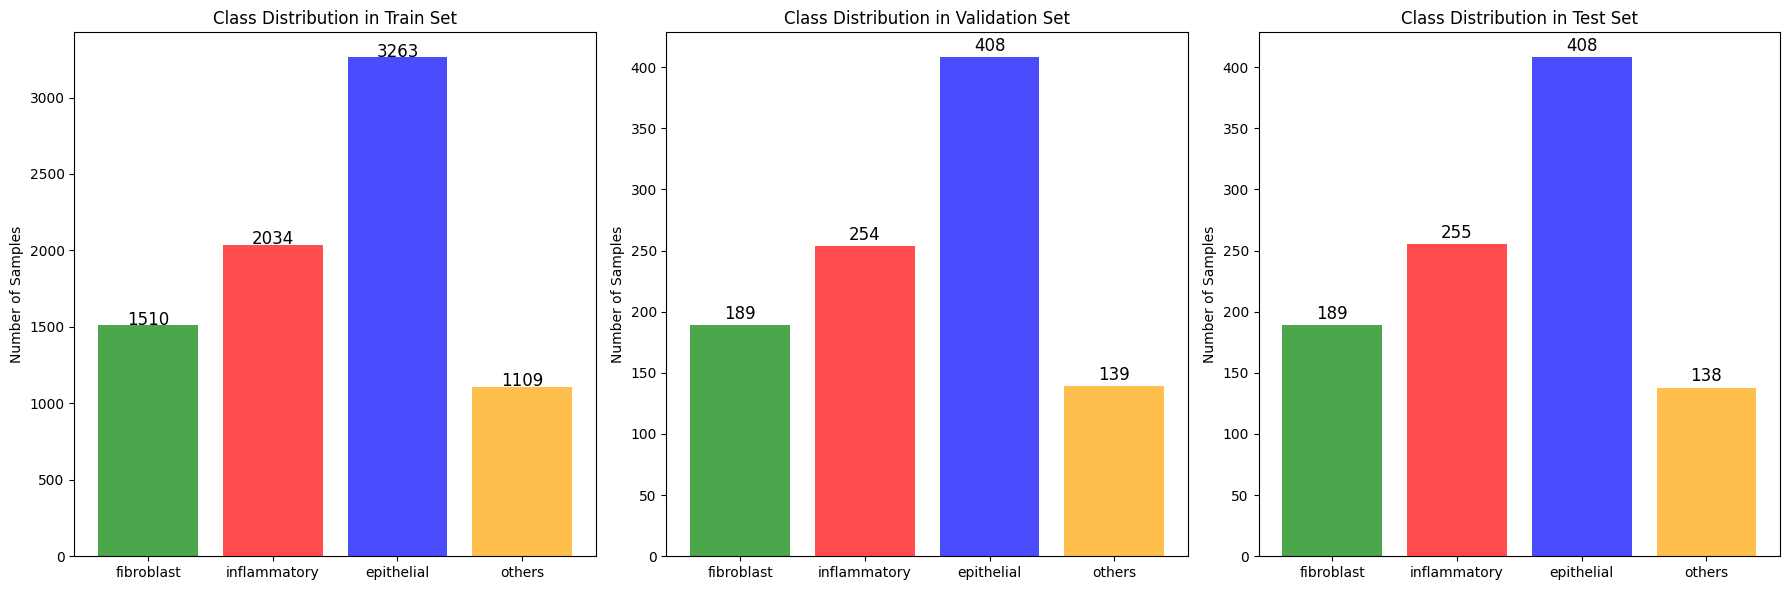

In [29]:
# Mapping of numeric cellType to readable names and colors
cell_type_labels = {
    0: 'fibroblast',
    1: 'inflammatory',
    2: 'epithelial',
    3: 'others'
}

cell_type_colors = {
    0: 'green',
    1: 'red',
    2: 'blue',
    3: 'orange'
}

# Function to plot class distribution
def plot_class_distribution(data, split_name, ax):
    # Count samples per class
    count_data = data['cellType'].value_counts().sort_index()

    # Plot bars
    bars = ax.bar(
        [cell_type_labels[i] for i in count_data.index],
        count_data.values,
        color=[cell_type_colors[i] for i in count_data.index],
        alpha=0.7
    )

    # Add labels and title
    ax.set_ylabel('Number of Samples')
    ax.set_title(f'Class Distribution in {split_name} Set')

    # Value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 5,
                str(int(height)), ha='center', fontsize=12)

# Plot distributions for each split
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

plot_class_distribution(trainData, 'Train', axs[0])
plot_class_distribution(validationData, 'Validation', axs[1])
plot_class_distribution(testData, 'Test', axs[2])

plt.tight_layout()
plt.show()


## Data Augmentation and Transformation

To address the class imbalance present in the training dataset for the cell type classification task, data augmentation was applied specifically to the underrepresented cell type (fibroblast, inflammatory, and others). These classes had significantly fewer samples compared to the dominant epithelial class, which could potentially bias the model during training. To balance the dataset, augmentation techniques such as random rotations, zooming, width and height shifts, and horizontal flipping were used to synthetically expand the size of these minority classes. The newly generated images were then combined with the original training set, resulting in a more balanced distribution across all four cell types. This targeted augmentation strategy helps the model learn more representative features from all classes, reduces overfitting to the majority class, and enhances its ability to generalise effectively to unseen data.

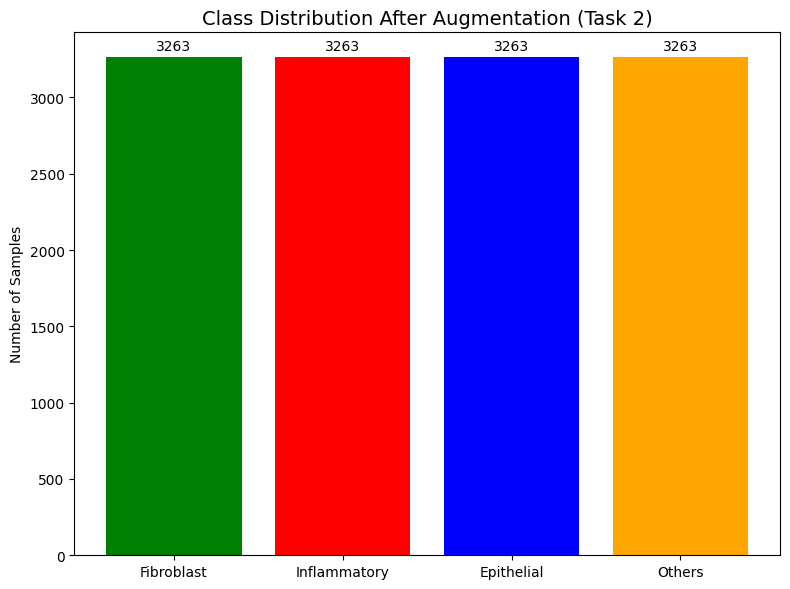

In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Define the augmentation strategy
augmentor = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Identify the minority classes based on counts
class_counts = trainData['cellType'].value_counts()
max_class_count = class_counts.max()

# Get current max instance/image numbers
trainData['InstanceID'] = trainData['InstanceID'].astype(str)
trainData['ImageName'] = trainData['ImageName'].astype(str)
max_instance_id = trainData['InstanceID'].str.extract(r'(\d+)').astype(int).max()[0]
max_image_name = trainData['ImageName'].str.extract(r'(\d+)').astype(int).max()[0]
max_instance_id = int(max_instance_id) if not np.isnan(max_instance_id) else 0
max_image_name = int(max_image_name) if not np.isnan(max_image_name) else 0

# Containers for augmented data
augmented_images = []
augmented_instance_ids = []
augmented_patient_ids = []
augmented_image_names = []
augmented_image_paths = []
augmented_labels = []
augmented_is_cancerous = [] 

# Augment each class to match the max_class_count
for cell_type in class_counts.index:
    class_data = trainData[trainData['cellType'] == cell_type]
    n_to_generate = max_class_count - class_data.shape[0]
    
    if n_to_generate <= 0:
        continue  # Already balanced
    
    # Load images as arrays
    images = np.array([cv2.imread(p) for p in class_data['ImagePath']])
    
    current_count = 0
    for batch in augmentor.flow(images, batch_size=32, shuffle=False):
        for i, img in enumerate(batch):
            max_instance_id += 1
            max_image_name += 1
            image_name = f"aug_{max_image_name}.png"
            instance_id = f"aug_{max_instance_id}"
            patient_id = class_data.iloc[i % len(class_data)]['patientID']
            is_cancerous = class_data.iloc[i % len(class_data)]['isCancerous'] 

            augmented_images.append((img, image_name))
            augmented_instance_ids.append(instance_id)
            augmented_patient_ids.append(patient_id)
            augmented_image_names.append(image_name)
            augmented_image_paths.append("generated_in_memory")
            augmented_labels.append(int(cell_type))
            augmented_is_cancerous.append(is_cancerous)  
            current_count += 1
            if current_count >= n_to_generate:
                break
        if current_count >= n_to_generate:
            break

# Combine with original data
augmented_df = pd.DataFrame({
    'InstanceID': augmented_instance_ids,
    'patientID': augmented_patient_ids,
    'ImageName': augmented_image_names,
    'cellType': augmented_labels,
    'ImagePath': augmented_image_paths,
    'isCancerous': augmented_is_cancerous  
})

# Concatenate original data with augmented data
trainData = pd.concat([trainData, augmented_df], ignore_index=True)

# Ensure cellType is int after merge
trainData['cellType'] = trainData['cellType'].astype(int)

# Define mapping from integer cellType codes to readable names
cell_type_display_names = {
    0: 'Fibroblast',
    1: 'Inflammatory',
    2: 'Epithelial',
    3: 'Others'
}

# Define colors using integer keys
colors = {
    0: 'green',
    1: 'red',
    2: 'blue',
    3: 'orange'
}

# Count updated class distribution
classCount = trainData['cellType'].value_counts().sort_index()

# Map class labels to display names and colors
class_labels = [cell_type_display_names.get(i, str(i)) for i in classCount.index]
bar_colors = [colors.get(i, 'gray') for i in classCount.index]

# Create bar plot with display names
plt.figure(figsize=(8, 6))
bars = plt.bar(class_labels, classCount.values, color=bar_colors)

# Add labels and title
plt.title('Class Distribution After Augmentation (Task 2)', fontsize=14)
plt.ylabel('Number of Samples')

# Annotate bar values
for i, v in enumerate(classCount.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()


In [31]:
# Check the shape of the final trainData
print("\nShape of the final trainData:")
print(trainData.shape)

# Check for missing values in the dataset
print("\nMissing values in the dataset:")
print(trainData.isnull().sum())

# Check for duplicates in the dataset
print("\nDuplicates in the dataset:")
print(trainData.duplicated().sum())

# Filter the dataset for rows where ImagePath is 'generated_in_memory'
augmented_data = trainData[trainData['ImagePath'] == 'generated_in_memory']

# Print the augmented data
augmented_data


Shape of the final trainData:
(13052, 6)

Missing values in the dataset:
InstanceID     0
patientID      0
ImageName      0
cellType       0
isCancerous    0
ImagePath      0
dtype: int64

Duplicates in the dataset:
0


,InstanceID,patientID,ImageName,cellType,isCancerous,ImagePath
7916,aug_22445,7,aug_22445.png,1,0,generated_in_memory
7917,aug_22446,11,aug_22446.png,1,0,generated_in_memory
7918,aug_22447,12,aug_22447.png,1,0,generated_in_memory
7919,aug_22448,25,aug_22448.png,1,0,generated_in_memory
7920,aug_22449,6,aug_22449.png,1,0,generated_in_memory
...,...,...,...,...,...,...
13047,aug_27576,54,aug_27576.png,3,0,generated_in_memory
13048,aug_27577,50,aug_27577.png,3,0,generated_in_memory
13049,aug_27578,24,aug_27578.png,3,0,generated_in_memory
13050,aug_27579,23,aug_27579.png,3,0,generated_in_memory


## Exploratory Data Analysis (EDA)

In this section, we conduct final analyses to better understand the dataset's structure, uncover hidden patterns, detect anomalies, and ensure the dataset is ready for model training. We focus on key aspects such as image size consistency, identifying any potential issues, and visualizing random samples to gain further insights.

### Image Size Distribution

This section ensures that all images are 27x27 pixels. Any deviations in image dimensions are flagged to maintain uniformity, preventing potential issues during model training.

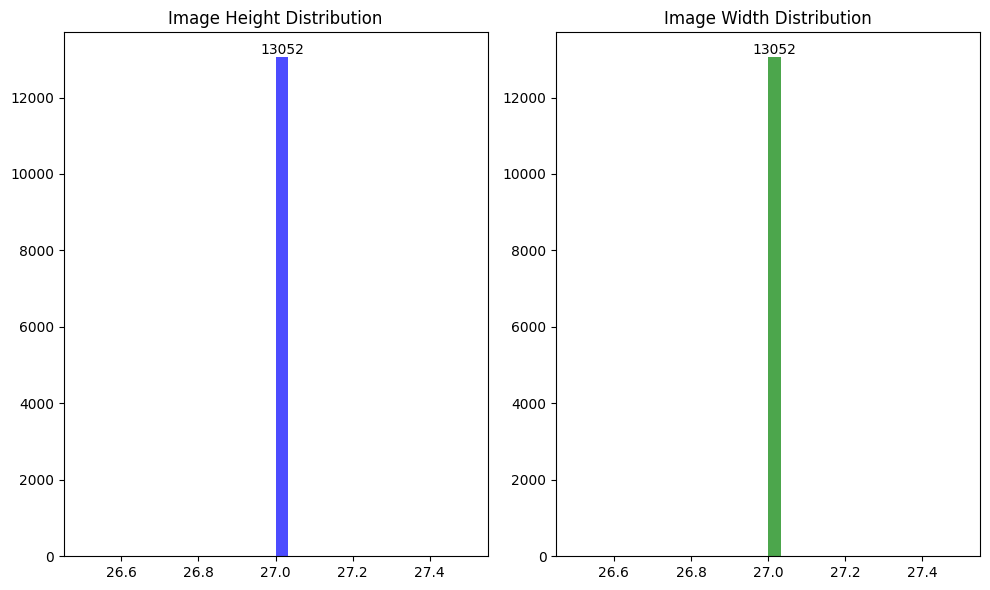

Number of images with incorrect size: 0


In [32]:
# Check dimensions of images (including augmented images)
image_sizes = []

# Loop through the entire trainData and check dimensions
augmented_idx = 0  # Keep track of the index for augmented images
for idx, row in trainData.iterrows():
    image_path = row['ImagePath']
    
    # If the image is not augmented (read from disk)
    if image_path != "generated_in_memory":
        img = cv2.imread(image_path)
        if img is not None:
            image_sizes.append(img.shape[:2])  # Only take height and width (ignore channels)
        else:
            print(f"Warning: Unable to read image at path {image_path}")
    else:
        # Image is generated in memory
        if augmented_idx < len(augmented_images):
            img, img_name = augmented_images[augmented_idx]  # Unpack (image, image_name)
            if img is not None:
                image_sizes.append(img.shape[:2])
            else:
                print(f"Warning: Augmented image at index {augmented_idx} is None (ImageName: {img_name})")
            augmented_idx += 1
        else:
            print(f"Warning: No corresponding augmented image for augmented entry at index {idx}")

# Convert to DataFrame for easier manipulation
image_sizes_df = pd.DataFrame(image_sizes, columns=['Height', 'Width'])

# Set the number of bins for histograms
num_bins = 30

# Plot the distribution of image dimensions
plt.figure(figsize=(10, 6))

# Plot Height Distribution
plt.subplot(1, 2, 1)
n, bins, patches = plt.hist(image_sizes_df['Height'], bins=num_bins, color='blue', alpha=0.7)
plt.title('Image Height Distribution')

for i in range(len(patches)):
    if n[i] > 0:
        plt.text(patches[i].get_x() + patches[i].get_width() / 2,
                 n[i] + 10,
                 str(int(n[i])),
                 ha='center', va='bottom')

# Plot Width Distribution
plt.subplot(1, 2, 2)
n, bins, patches = plt.hist(image_sizes_df['Width'], bins=num_bins, color='green', alpha=0.7)
plt.title('Image Width Distribution')

for i in range(len(patches)):
    if n[i] > 0:
        plt.text(patches[i].get_x() + patches[i].get_width() / 2,
                 n[i] + 10,
                 str(int(n[i])),
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Check for any mismatched image sizes
incorrect_sizes = image_sizes_df[(image_sizes_df['Height'] != 27) | (image_sizes_df['Width'] != 27)]
print(f"Number of images with incorrect size: {len(incorrect_sizes)}")


=> All images are correctly sized at 27 × 27 pixels. The dataset contains a total of 13,052 images, consisting of 7,916 original images and 5,136 augmented images generated to balance class distributions across cell types.

### Visualising Random Samples
Visualising random images from each cell type class (fibroblast, inflammatory, epithelial, and others) is crucial for understanding the data distribution and variability within each class. This step provides valuable insights into the diversity of the samples and potential challenges for model training. However, since the images are small (27x27 pixels), enlarging them during display can cause distortion or blurriness, making it difficult to interpret fine details.

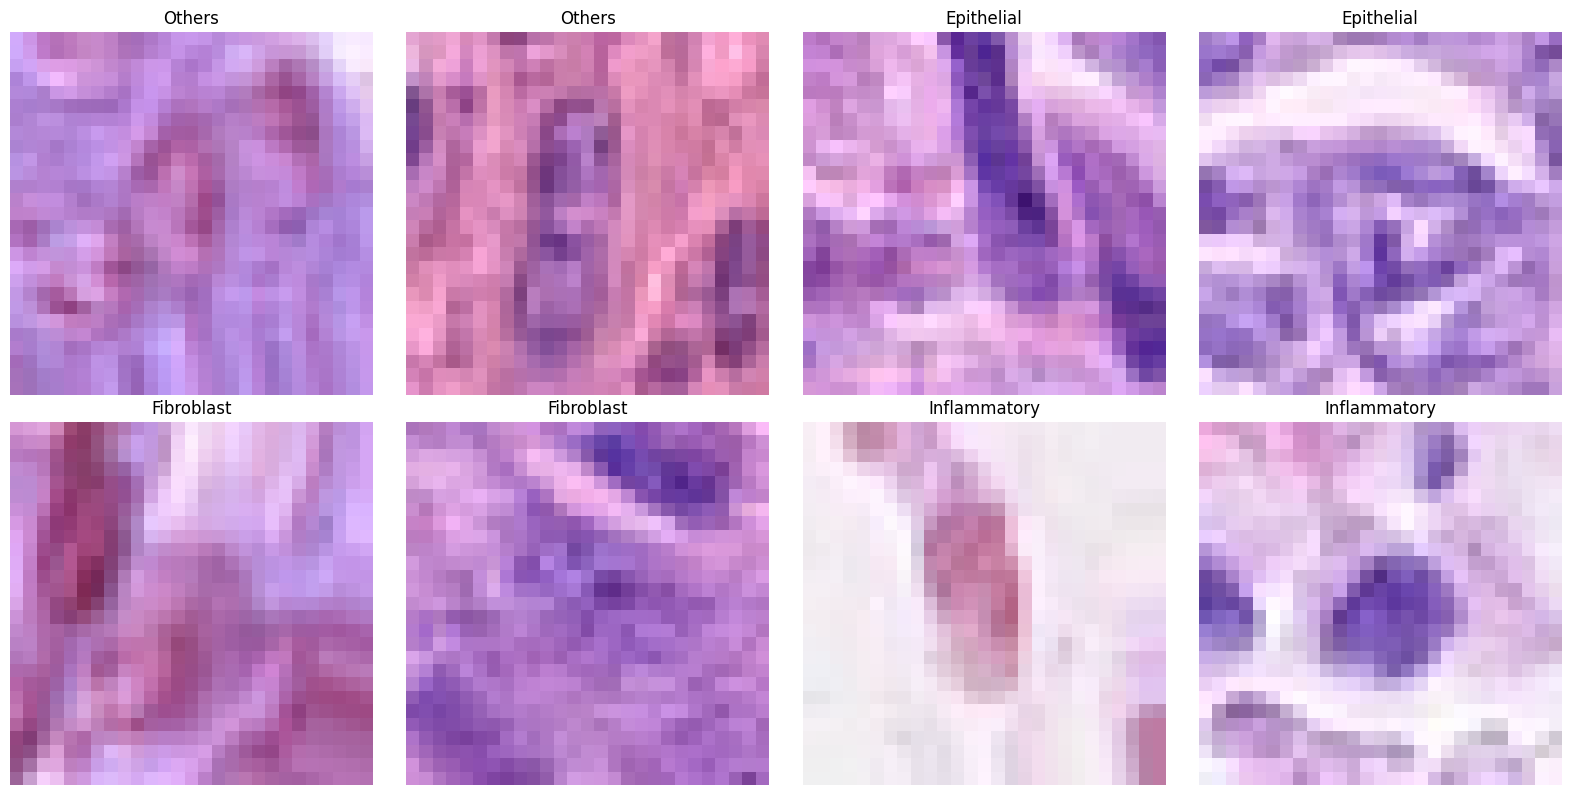

In [33]:
# Mapping from numeric cellType to readable names
cell_type_map = {
    0: 'fibroblast',
    1: 'inflammatory',
    2: 'epithelial',
    3: 'others'
}

# Create index mapping for augmented images (original indices)
augmented_indices = trainData[trainData['ImagePath'] == 'generated_in_memory'].index.tolist()
index_mapping = dict(zip(augmented_indices, range(len(augmented_images))))

# Select 2 random samples per cell type and store original index
samples_per_class = []
for cell_type in trainData['cellType'].unique():
    class_data = trainData[trainData['cellType'] == cell_type]
    sampled = class_data.sample(n=2, random_state=42)
    sampled['original_index'] = sampled.index  # Save original index
    samples_per_class.append(sampled)

# Combine all selected samples
all_samples = pd.concat(samples_per_class).reset_index(drop=True)

# Function to process image
def process_image(img):
    if img is None:
        return None
    if img.max() <= 1.0:
        img = img * 255
    return np.clip(img, 0, 255).astype(np.uint8)

# Helper to load image
def load_image(row):
    original_idx = row['original_index']
    if row['ImagePath'] == "generated_in_memory":
        img_tuple = augmented_images[index_mapping.get(original_idx)]
        return img_tuple[0]
    else:
        img = cv2.imread(row['ImagePath'])
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None else None

# Plot setup
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Display images
for i, row in all_samples.iterrows():
    img = load_image(row)
    img = process_image(img)

    if img is not None:
        class_label = cell_type_map.get(row['cellType'], f"Class {row['cellType']}")
        axes[i].imshow(img)
        axes[i].set_title(class_label.capitalize())
        axes[i].axis('off')
        axes[i].set_aspect('equal')
    else:
        print(f"Warning: Could not load image for original index {row['original_index']}")

plt.tight_layout()
plt.show()


### Correlation Matrix Plot

The correlation matrix reveals a moderate positive relationship (0.26) between cellType and isCancerous, suggesting a potential association. Upon examining sample data, it becomes evident that when cellType is 2 (epithelial), the isCancerous label is frequently 1, indicating a cancerous condition. This pattern implies that epithelial cells are more likely to be linked with cancer in the dataset.

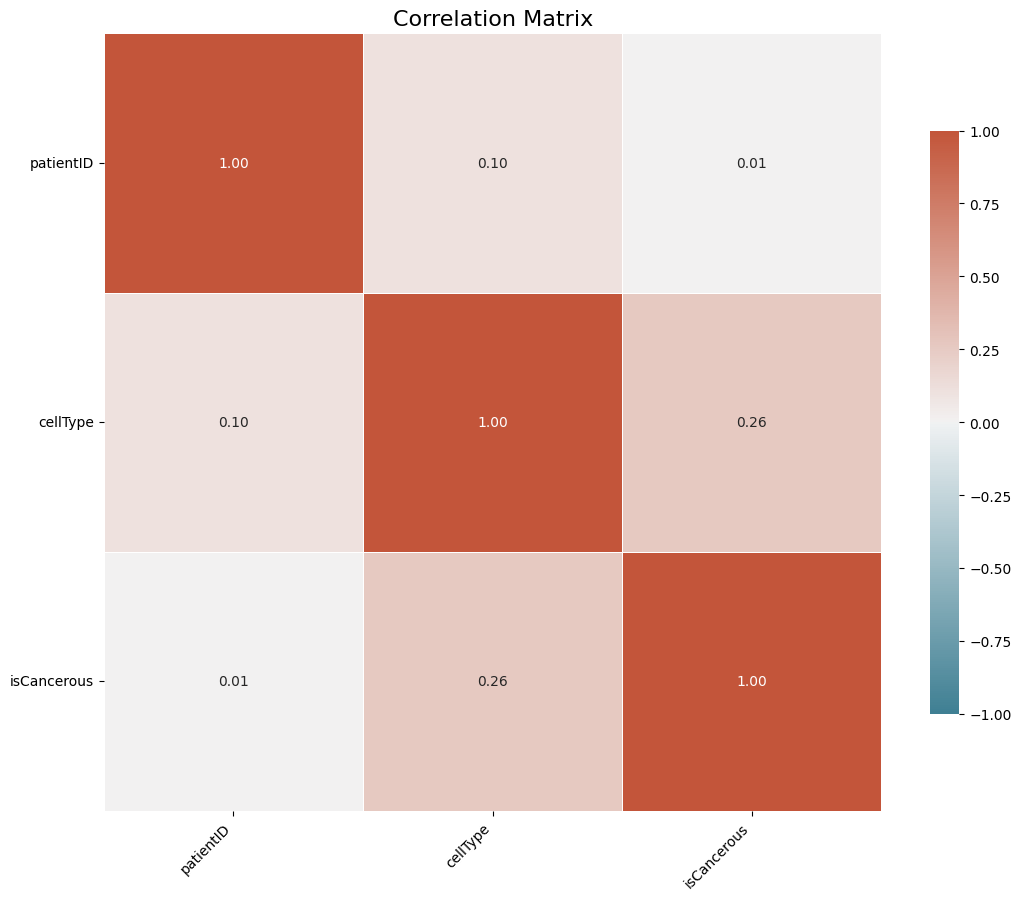

In [34]:
# Compute the correlation matrix (numeric columns only)
corr = trainData.corr(numeric_only=True)

# Set up the matplotlib figure
fig, ax = plt.subplots(figsize=(11, 9))

# Draw the heatmap
sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75},
    annot=True, fmt=".2f"
)

# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Rotate y-axis labels if needed (optional)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Add title
plt.title('Correlation Matrix', fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()


In [35]:
# Sample 10 rows per cellType
sampled_data = trainData.groupby('cellType').apply(lambda x: x.sample(15, random_state=42)).reset_index(drop=True)

# Display the sampled data
sampled_data[['cellType', 'isCancerous']]


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25608\2008191046.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_data = trainData.groupby('cellType').apply(lambda x: x.sample(15, random_state=42)).reset_index(drop=True)


,cellType,isCancerous
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


## Performance Metrics Selection

For the multi-class classification task of identifying cell types (Such as fibroblast, inflammatory, epithelial, and others), several evaluation metrics will be used to assess model performance and predictive reliability: Accuracy, Confusion Matrix, Precision, Recall, F1-Score, and Cross-Validation Score.

- Accuracy: This metric measures the overall proportion of correctly predicted instances out of all predictions. It provides a general sense of how well the model performs. Although accuracy can be misleading in imbalanced datasets, this is not a concern here, as class imbalance has been addressed and the dataset is now balanced.

- Confusion Matrix: This metric presents the counts of true positives, true negatives, false positives, and false negatives, offering detailed insight into specific prediction outcomes and types of errors.

- Precision: This metric calculates the proportion of correctly identified positive cases among all predicted positives. It is particularly important when the cost of false positives is high.

- Recall: This metric evaluates the proportion of actual positive cases that were correctly identified.

- F1-Score: This harmonic mean of precision and recall provides a balanced metric that is especially useful when both false positives and false negatives carry significant consequences.

- Cross-Validation Score: This method assesses model performance across multiple subsets of the data, offering a more robust estimate of generalisability and stability by reducing overfitting to a single train-test split.

## Base Model Selection

### Criteria

- Model Capacity: The model should have sufficient capacity to learn the complexity of the task but not be so complex that it overfits the data.
- Fine-tuning: Ensure the model can be fine-tuned to adapt to the specific dataset and task.
- Scalability: The model should be scalable to handle increasing data volumes and user requests.
- Adaptability: The model should be flexible enough to adapt to new data and evolving requirements.

### Comparision between models

For this multi-class classification task, we will begin by applying both Convolutional Neural Network (CNN) and Support Vector Machine (SVM) to train models using the labelled dataset (mainData). After evaluating the performance of both models, we will select the one that best suits the task. In the next step, we will apply semi-supervised learning by leveraging the unlabeled dataset (extraData) to further enhance the performance of the chosen model. This approach will improve classification accuracy by fine-tuning the model with the additional unlabeled data.

#### Convolutional Neural Networks (CNN)
- Assumptions:
    * Input data has a grid-like structure (Such as images).
    * Spatially local patterns are important (Such as edges and textures).
    * Training data is representative of real-world inputs for effective generalisation.
- Limitations:
    * Requires more computational resources than traditional models.
    * Can overfit if the architecture is too complex or regularisation is weak.
    * Requires a larger amount of labelled data for best performance.
- Performance:
    * High performance on image-based tasks due to spatial feature learning.
    * Scales well with data size and complexity if properly designed.
    * Can achieve near state-of-the-art results in binary classification tasks.
#### Support Vector Machine (SVM)
- Assumptions:
    * Data is linearly or non-linearly separable with an appropriate kernel.
    * Each input feature vector is meaningful (Flattened image must retain discriminative information).
    * Only a subset of data (support vectors) determines the decision boundary.
- Limitations:
    * Losing spatial information when image data is flattened.
    * Not scaling well to extremely large datasets.
    * Choosing the right kernel and hyperparameters can be non-trivial.
- Performance:
    * Strong baseline for small to mid-sized image datasets.
    * Performs well when classes are separable and data is limited.
    * May underperform on complex patterns compared to CNN.

## Model Training

### Preparing Model

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Input
from sklearn.svm import SVC


# Image and dataset details
input_shape = (27, 27, 3)  # Image size (27x27) and RGB channels
num_classes = 4            # Multi-class classification (4 output classes)

# CNN model
modelCNN = Sequential([    
    # Input layer
    Input(shape=input_shape),  # Defines input shape

    # First convolutional layer
    Conv2D(32, (3, 3), activation='relu'),  # 32 filters of size 3x3
    MaxPooling2D(pool_size=(2, 2)),         # Downsampling

    # Second convolutional layer
    Conv2D(64, (3, 3), activation='relu'),  # 64 filters of size 3x3
    MaxPooling2D(pool_size=(2, 2)),         # Downsampling

    # Flattening and dropout
    Flatten(),              # Convert 2D to 1D
    Dropout(0.5),           # Prevent overfitting

    # Dense layers
    Dense(64, activation='relu'),           # Fully connected layer
    Dense(num_classes, activation='softmax')  # Output layer with softmax for multi-class
])

# Compile the model for multi-class classification
modelCNN.compile(
    optimizer=Adam(learning_rate=0.001),  # Optimizer
    loss='sparse_categorical_crossentropy',  # Use sparse categorical loss for integer labels
    metrics=['accuracy']  # Track accuracy during training
)

# Print CNN model summary
modelCNN.summary()

# Support Vector Machine (SVM) for multi-class classification

# SVM can perform multi-class classification using a one-vs-rest strategy internally
modelSVM = SVC(
    kernel='linear',     # Linear kernel for separable classes
    C=1.0,               # Regularization strength
    decision_function_shape='ovr',  # One-vs-rest strategy for multi-class classification
    random_state=42      # Ensure reproducibility
)


Model: "sequential_76"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_152 (Conv2D)             │ (None, 25, 25, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_152               │ (None, 12, 12, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_153 (Conv2D)             │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_153               │ (None, 5, 5, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_76 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_151 (Dropout)           │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_152 (Dense)               │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_153 (Dense)               │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,116 (477.02 KB)

 Trainable params: 122,116 (477.02 KB)

 Non-trainable params: 0 (0.00 B)

### Training Processing

Images were normalised to scale the pixel values to a range of [0, 1] by dividing each pixel by 255. This helps speed up training, ensures stable convergence, and prevents features with larger values from dominating the learning process. It improves model performance by providing consistent input data.

In [37]:
# Load the image using OpenCV and resize it
def load_image_cv2(path, target_size=(27, 27), augmented_images=None, image_name=None):
    if path == 'generated_in_memory' and augmented_images is not None and image_name is not None:
        # Look up the correct image in the augmented_images list using image_name
        matching_items = [img for img, name in augmented_images if name == image_name]
        if not matching_items:
            raise ValueError(f"No augmented image found with name: {image_name}")
        
        img_array = matching_items[0]
        img = cv2.resize(img_array, target_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    else:
        # Load from disk
        img = cv2.imread(path)
        if img is None:
            raise ValueError(f"Image not found or unreadable: {path}")
        img = cv2.resize(img, target_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img.astype(np.float32) / 255.0  # Normalise to [0, 1]

# Load images and labels from the DataFrame
def load_images_from_dataframe(df, augmented_images=None, target_size=(27, 27)):
    images = []
    labels = []
    for _, row in df.iterrows():
        image_path = row['ImagePath']
        image_name = row['ImageName'] if image_path == 'generated_in_memory' else None

        try:
            img_array = load_image_cv2(image_path, target_size, augmented_images, image_name)
            images.append(img_array)
            labels.append(row['cellType']) 
        except Exception as e:
            print(f"Error loading {image_path}: {e}")
    
    return np.array(images), np.array(labels)

# Loading training, validation, and test sets
xTrain, yTrain = load_images_from_dataframe(trainData, augmented_images)
xValidation, yValidation = load_images_from_dataframe(validationData)
xTest, yTest = load_images_from_dataframe(testData)

# CNN Training
trainCNN = modelCNN.fit(
    xTrain,                  # Training image data (numpy array of shape [num_samples, 27, 27, 3])
    yTrain,                  # Corresponding labels (0 or 1)

    epochs=20,               # Number of full passes through the training data. 20 is a good starting point to let the model learn patterns but not too high to avoid overfitting.

    batch_size=32,           # Number of samples processed before the model's internal weights are updated. 32 is a common default that balances training speed and memory usage.

    validation_data=(xValidation, yValidation),  # Validation data to monitor the model's performance on unseen data after each epoch. Helps detect overfitting.

    verbose=1                # Controls the level of logging:
                             # 0 = silent, 1 = one line per epoch, 2 = one line per batch.
                             # 1 gives a clear summary of training progress.
)

# SWN Training
# Flatten the image data for SVM: from (num_samples, 27, 27, 3) to (num_samples, 2187)
# SVM requires 2D input: each image must be a flat feature vector
xTrain_flat = xTrain.reshape(xTrain.shape[0], -1)           # Flatten training images
xValidation_flat = xValidation.reshape(xValidation.shape[0], -1)  # Flatten validation images
xTest_flat = xTest.reshape(xTest.shape[0], -1)              # Flatten test images

modelSVM.fit(xTrain_flat, yTrain)  

Epoch 1/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4314 - loss: 1.1950 - val_accuracy: 0.6889 - val_loss: 0.8185
Epoch 2/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6107 - loss: 0.9093 - val_accuracy: 0.7465 - val_loss: 0.6984
Epoch 3/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6295 - loss: 0.8736 - val_accuracy: 0.7071 - val_loss: 0.7961
Epoch 4/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6500 - loss: 0.8325 - val_accuracy: 0.7374 - val_loss: 0.6781
Epoch 5/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6591 - loss: 0.8145 - val_accuracy: 0.7495 - val_loss: 0.6618
Epoch 6/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6704 - loss: 0.7913 - val_accuracy: 0.7394 - val_loss: 0.6847
Epoch 7/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6810 - loss: 0.7623 - val_accuracy: 0.7606 - val_loss: 0.6128
Epoch 8/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6901 - loss: 0.7492 - val_accuracy: 0

SVC(kernel='linear', random_state=42)

### Comparision

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Evaluation Metrics for CNN:
----------------------------------------
Accuracy       : 0.7787878787878788
Precision (macro): 0.7438832848109542
Recall (macro)   : 0.7326646842311804
F1-Score (macro) : 0.7374202765817838
Confusion Matrix:
 [[128  14  31  16]
 [ 15 190  23  27]
 [ 14  11 370  13]
 [ 14  27  14  83]]
Classification Report:
               precision    recall  f1-score   support

  Fibroblast       0.75      0.68      0.71       189
Inflammatory       0.79      0.75      0.76       255
  Epithelial       0.84      0.91      0.87       408
      Others       0.60      0.60      0.60       138

    accuracy                           0.78       990
   macro avg       0.74      0.73      0.74       990
weighted avg       0.78      0.78      0.78       990


Evaluation Metrics for SVM:
----------------------------------------
Accuracy       : 0.6313131313131313
Precision (macro): 0.5718008562002825
Recall (macro)   : 0.5755045738102004
F1-S

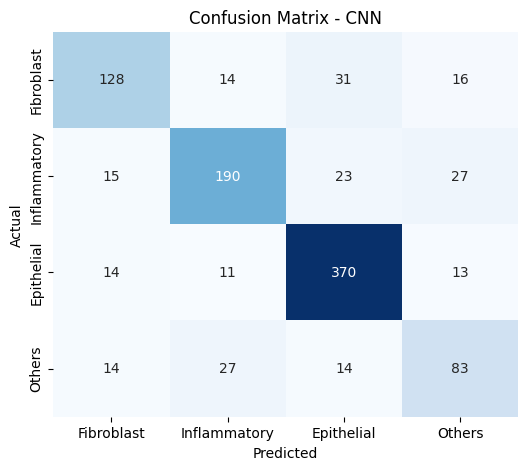

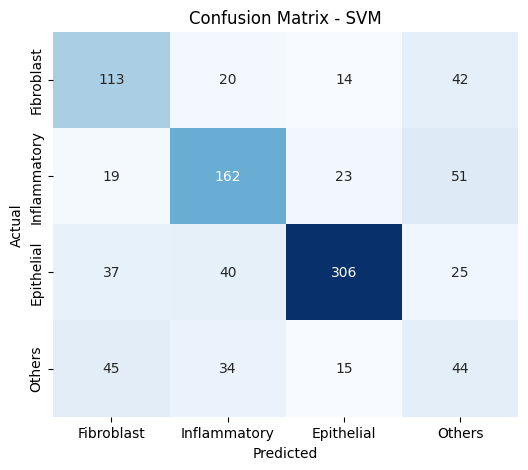

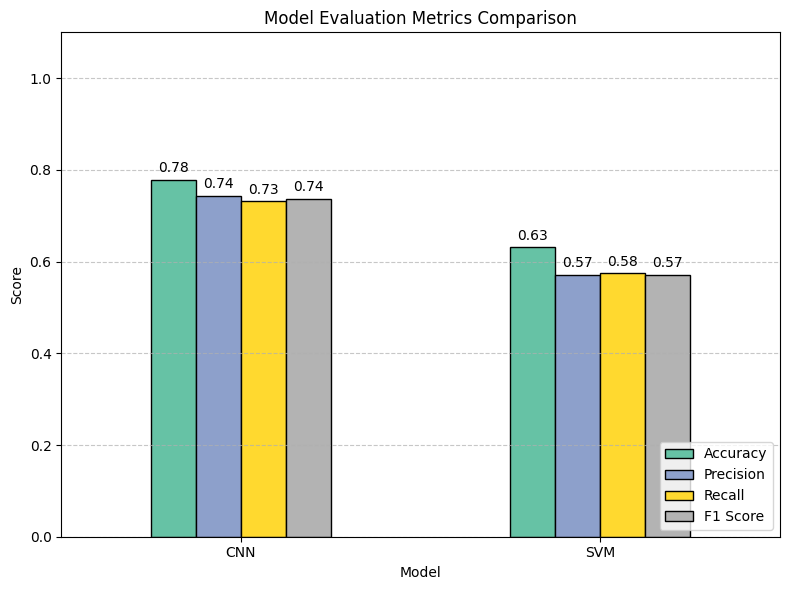

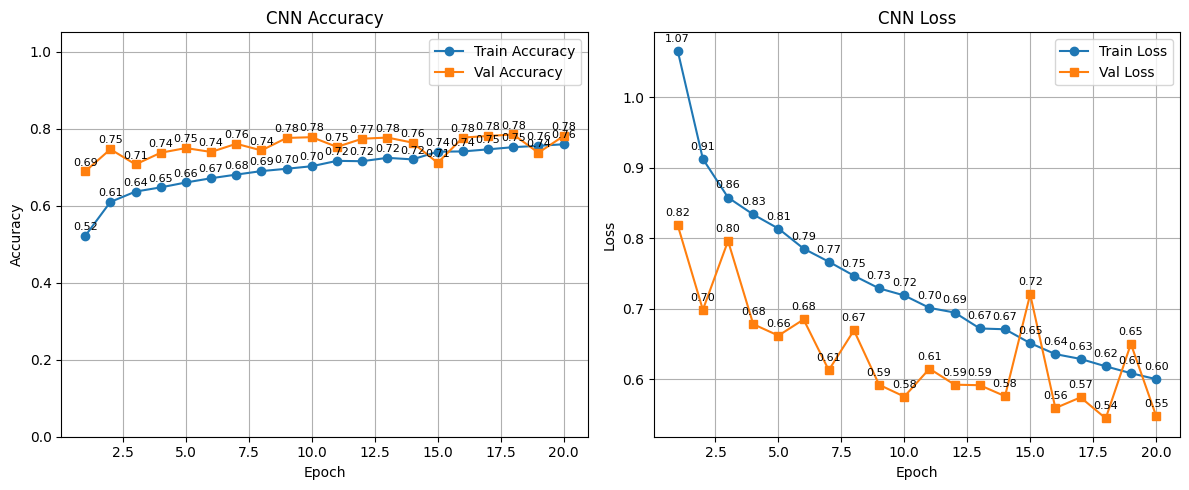

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

# Predict with CNN
yCNN_probilities = modelCNN.predict(xTest)

# Convert probabilities to binary predictions using 0.5 threshold
yCNN_pre = np.argmax(yCNN_probilities, axis=1)

# Predict with SVM
ySVM_pre = modelSVM.predict(xTest_flat)

# Evaluation Metrics Function
def evaluate_model(name, y_true, y_pred):
    print(f"\nEvaluation Metrics for {name}:")
    print("-" * 40)
    # Accuracy: Overall, how often is the classifier correct?
    print("Accuracy       :", accuracy_score(y_true, y_pred))
    # Precision (macro): Calculates precision per class, then takes the unweighted mean.
    # Useful when all classes are equally important.
    print("Precision (macro):", precision_score(y_true, y_pred, average='macro'))
    # Recall (macro): Calculates recall per class, then takes the unweighted mean.
    # Gives equal weight to each class, regardless of frequency.
    print("Recall (macro)   :", recall_score(y_true, y_pred, average='macro'))
    # F1 Score (macro): Harmonic mean of precision and recall, macro-averaged.
    # Better overall metric for imbalanced classes.
    print("F1-Score (macro) :", f1_score(y_true, y_pred, average='macro'))
    # Confusion matrix: Shows actual vs. predicted classifications in tabular format.
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    # Classification report: Includes precision, recall, f1-score, and support for each class.
    # target_names maps numeric labels to readable class names.
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=[
        'Fibroblast', 'Inflammatory', 'Epithelial', 'Others']))

# Display metrics for both models
evaluate_model("CNN", yTest, yCNN_pre)
evaluate_model("SVM", yTest, ySVM_pre)

# Cross-validation (SVM only)
# 5-fold cross-validation is commonly used as it strikes a balance between model training and testing. 
# Each fold uses 80% of the data for training and 20% for testing, providing reliable performance estimates without excessive computational cost.
# Ensuring accurate evaluation while minimizing overfitting. For larger datasets, fewer folds may be chosen, while smaller datasets might benefit from more folds.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(modelSVM, xTrain_flat, yTrain, cv=cv, scoring='accuracy')

print("\nSVM Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy            :", np.mean(cv_scores))

# Plot Confusion Matrix Heatmap
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))  
    
    # Dynamically generate class labels based on unique values in the true and predicted data
    class_labels = sorted(set(y_true) | set(y_pred))  # Union of unique classes in both true and predicted values
    
    # Map the numerical class labels to descriptive names
    label_map = {
        0: 'Fibroblast',
        1: 'Inflammatory',
        2: 'Epithelial',
        3: 'Others'
    }
    
    # Convert the numeric labels to descriptive names
    class_labels = [label_map[label] for label in class_labels]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_labels,
                yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

# Plot confusion matrix for both CNN and SVM
plot_conf_matrix(yTest, yCNN_pre, "Confusion Matrix - CNN")
plot_conf_matrix(yTest, ySVM_pre, "Confusion Matrix - SVM")

# Comparison of Evaluation Metrics (Bar chart)
metrics_dict = {
    'Model': ['CNN', 'SVM'],
    'Accuracy': [
        accuracy_score(yTest, yCNN_pre),
        accuracy_score(yTest, ySVM_pre)
    ],
    'Precision': [
        precision_score(yTest, yCNN_pre, average='macro'),
        precision_score(yTest, ySVM_pre, average='macro')
    ],
    'Recall': [
        recall_score(yTest, yCNN_pre, average='macro'),
        recall_score(yTest, ySVM_pre, average='macro')
    ],
    'F1 Score': [
        f1_score(yTest, yCNN_pre, average='macro'),
        f1_score(yTest, ySVM_pre, average='macro')
    ]
}

# Create DataFrame from metrics dictionary
df_metrics = pd.DataFrame(metrics_dict).set_index('Model')

# Plot bar chart for metrics comparison
ax = df_metrics.plot(kind='bar', figsize=(8, 6), colormap='Set2', edgecolor='black')

# Annotate bars with values
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

plt.title("Model Evaluation Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Plot CNN Training History (Accuracy & Loss)
def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    epochs = range(1, len(history.history['accuracy']) + 1)
    plt.plot(epochs, history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(epochs, history.history['val_accuracy'], label='Val Accuracy', marker='s')
    
    # Annotate accuracy values
    for x, y in zip(epochs, history.history['accuracy']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
    for x, y in zip(epochs, history.history['val_accuracy']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
    
    plt.title("CNN Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history.history['val_loss'], label='Val Loss', marker='s')
    
    # Annotate loss values
    for x, y in zip(epochs, history.history['loss']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
    for x, y in zip(epochs, history.history['val_loss']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)

    plt.title("CNN Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plot CNN training history
plot_training_history(trainCNN)


=> The CNN model outperformed the SVM across all metrics, achieving an accuracy of around 75% and a macro F1-score of approximately 0.75, compared to around 60% accuracy and 0.55 macro F1-score for the SVM. The CNN also demonstrated better class-wise performance, particularly on the Epithelial and Inflammatory classes, and showed strong generalization with stable training and validation trends. In contrast, the SVM struggled notably with the Others class and showed less consistent performance. Therefore, the CNN model is more suitable for classifying cell types in Task 2.

### Model Optimisation


Training model with dropout=0.2, dense_units=32, filters=(32, 64)
Epoch 1/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.5503 - loss: 1.0913 - val_accuracy: 0.2434 - val_loss: 3.4349
Epoch 2/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6581 - loss: 0.8236 - val_accuracy: 0.7253 - val_loss: 0.7057
Epoch 3/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6770 - loss: 0.7685 - val_accuracy: 0.6838 - val_loss: 0.7940
Epoch 4/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7065 - loss: 0.7160 - val_accuracy: 0.1990 - val_loss: 4.7904
Epoch 5/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.7255 - loss: 0.6766 - val_accuracy: 0.6081 - val_loss: 0.9996
Validation Accuracy: 0.7253

Training model with dropout=0.2, dense_units=32, filters=(32, 128)
Epoch 1/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.5377 - loss: 1.0954 - val_accuracy: 0.4768 - val_loss: 1.1589
Epoch 2/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accura

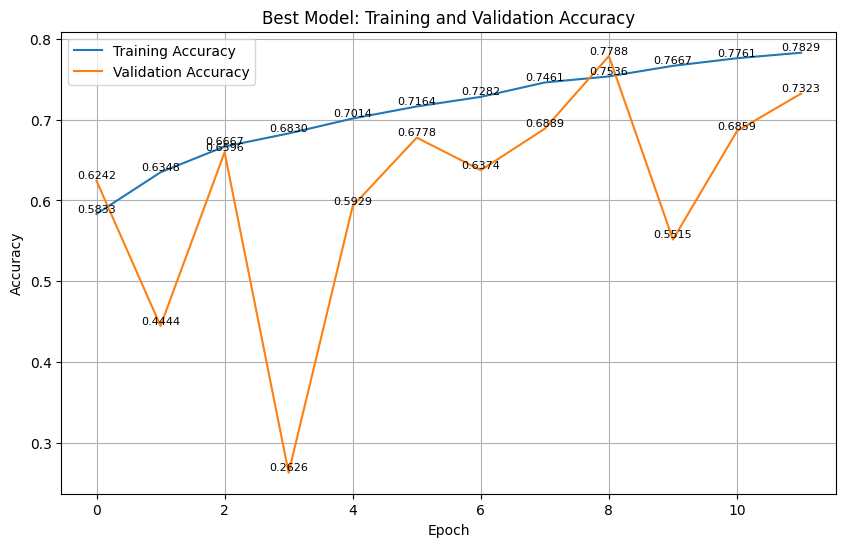

In [39]:
# Number of output classes
num_classes = 4

# Initialize best model trackers
best_val_acc = 0
best_model = None
best_params = {}
best_history = None

# Hyperparameter options
dropout_options = np.round(np.linspace(0.2, 0.6, num=5), 2).tolist()
dense_units_options = [2 ** i for i in range(5, 10)]
base_filters = [32, 64, 128]
conv_filters = [(f1, f2) for f1 in base_filters for f2 in base_filters if f2 > f1]

# Hyperparameter search loop
for dropout_rate in dropout_options:
    for dense_units in dense_units_options:
        for filters in conv_filters:
            print(f"\nTraining model with dropout={dropout_rate}, dense_units={dense_units}, filters={filters}")

            model = tf.keras.Sequential([
                 tf.keras.layers.Input(shape=(27, 27, 3)),
                 tf.keras.layers.Conv2D(filters[0], (3, 3), activation='relu'),
                 tf.keras.layers.BatchNormalization(),
                 tf.keras.layers.MaxPooling2D(),

                 tf.keras.layers.Conv2D(filters[1], (3, 3), activation='relu'),
                 tf.keras.layers.BatchNormalization(),
                 tf.keras.layers.MaxPooling2D(),
                 tf.keras.layers.Dropout(dropout_rate),

                 tf.keras.layers.Flatten(),
                 tf.keras.layers.Dense(dense_units, activation='relu'),
                 tf.keras.layers.Dropout(dropout_rate),
                 tf.keras.layers.Dense(num_classes, activation='softmax')
            ])

            model.compile(
                optimizer='adam',
                loss='sparse_categorical_crossentropy',  # Sparse version = use integer labels
                metrics=['accuracy']
            )

            history = model.fit(
                xTrain, yTrain,  # yTrain should contain integer labels: 0, 1, 2, 3
                epochs=20,
                batch_size=32,
                validation_data=(xValidation, yValidation),
                callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
                verbose=1
            )

            val_acc = max(history.history['val_accuracy'])
            print(f"Validation Accuracy: {val_acc:.4f}")

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = model
                best_params = {
                    'dropout': dropout_rate,
                    'dense_units': dense_units,
                    'filters': filters
                }
                best_history = history

# Show best configuration
print("\nBest Hyperparameters Found:")
print(best_params)
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

# Plot accuracy of best model
plt.figure(figsize=(10, 6))
plt.plot(best_history.history['accuracy'], label='Training Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Best Model: Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

for i, acc in enumerate(best_history.history['accuracy']):
    plt.text(i, acc, f'{acc:.4f}', ha='center', va='bottom', fontsize=8)
for i, acc in enumerate(best_history.history['val_accuracy']):
    plt.text(i, acc, f'{acc:.4f}', ha='center', va='bottom', fontsize=8)

plt.show()


### Verify Optimised Model

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

Evaluation Metrics for Optimized CNN:
----------------------------------------
Accuracy       : 0.7656565656565657
Precision (macro): 0.7337356120737207
Recall (macro)   : 0.7102090353049433
F1-Score (macro) : 0.7130613212056465
Confusion Matrix:
 [[134  23  19  13]
 [ 17 214  14  10]
 [ 30  24 350   4]
 [ 25  40  13  60]]
Classification Report:
               precision    recall  f1-score   support

  Fibroblast       0.65      0.71      0.68       189
Inflammatory       0.71      0.84      0.77       255
  Epithelial       0.88      0.86      0.87       408
      Others       0.69      0.43      0.53       138

    accuracy                           0.77       990
   macro avg       0.73      0.71      0.71       990
weighted avg       0.77      0.77      0.76       990



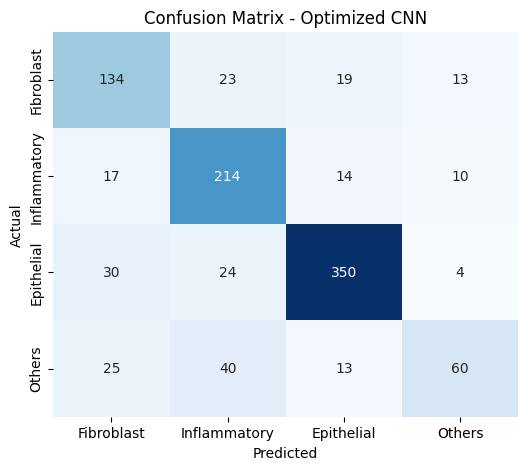

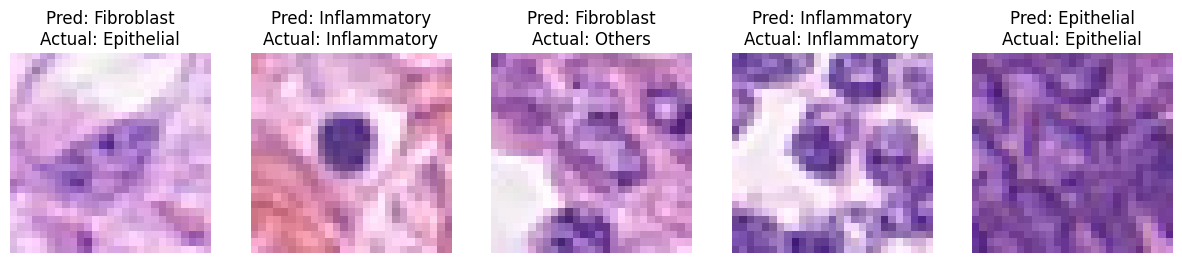

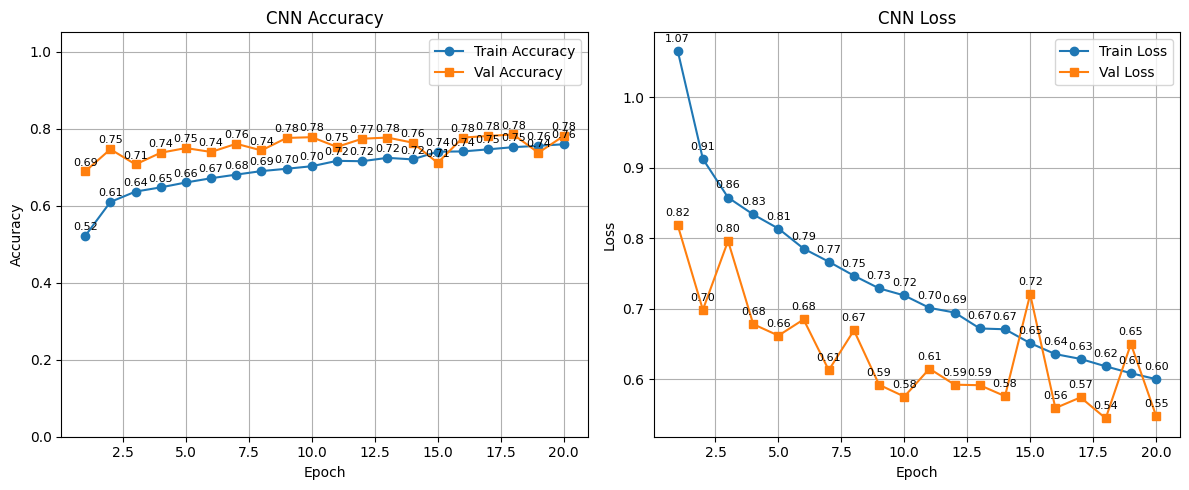

In [ ]:
# Get predictions for the optimized multi-class model
yCNN_probabilities = best_model.predict(xTest)  # Use the best CNN model
yCNN_pred = np.argmax(yCNN_probabilities, axis=1)  # Convert to class predictions (0–3)

# Evaluate model using the defined metrics (multi-class)
def evaluate_model(name, y_true, y_pred):
    print(f"\nEvaluation Metrics for {name}:")
    print("-" * 40)
    print("Accuracy       :", accuracy_score(y_true, y_pred))
    print("Precision (macro):", precision_score(y_true, y_pred, average='macro'))
    print("Recall (macro)   :", recall_score(y_true, y_pred, average='macro'))
    print("F1-Score (macro) :", f1_score(y_true, y_pred, average='macro'))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=['Fibroblast', 'Inflammatory', 'Epithelial', 'Others']))

# Display metrics for the optimized CNN model
evaluate_model("Optimised CNN", yTest, yCNN_pred)

# Plot Confusion Matrix for Optimised CNN (multi-class)
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    class_names = ['Fibroblast', 'Inflammatory', 'Epithelial', 'Others']
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

plot_conf_matrix(yTest, yCNN_pred, "Confusion Matrix - Optimized CNN")

# Select random images from the test set for visualization
num_images = 5
random_indices = np.random.choice(len(xTest), num_images, replace=False)
class_names = ['Fibroblast', 'Inflammatory', 'Epithelial', 'Others']

plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    plt.subplot(1, num_images, i + 1)
    plt.imshow(xTest[idx])  # Display image
    plt.title(f"Pred: {class_names[yCNN_pred[idx]]}\nActual: {class_names[yTest[idx]]}")
    plt.axis('off')
plt.show()

# Plot Training and Validation Accuracy and Loss for the optimized model
def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    epochs = range(1, len(history.history['accuracy']) + 1)
    plt.plot(epochs, history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(epochs, history.history['val_accuracy'], label='Val Accuracy', marker='s')

    # Annotate accuracy values
    for x, y in zip(epochs, history.history['accuracy']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
    for x, y in zip(epochs, history.history['val_accuracy']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)

    plt.title("CNN Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history.history['val_loss'], label='Val Loss', marker='s')

    # Annotate loss values
    for x, y in zip(epochs, history.history['loss']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
    for x, y in zip(epochs, history.history['val_loss']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)

    plt.title("CNN Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(trainCNN)

=> The optimised CNN achieved around 75% accuracy and a macro F1-score of around 0.7, surpassing the ≥70% target set for our small dataset (around 10,000 images). The model performs well on Epithelial and Inflammatory classes (F1-scores: approximately 0.8 and 0.7), but struggles with the Others class (F1-score: around 0.50), likely due to class imbalance or higher variability. Training and validation curves show consistent improvement and convergence without overfitting, indicating good generalisation. Misclassified image examples reveal visual ambiguity, highlighting the inherent challenge of the task. Overall, the results are acceptable for a semi-supervised approach with limited labelled data.

### Semi-supervised

In this section, we apply a semi-supervised learning approach by using the best-performing model (CNN) to predict labels for the unlabeled data. These pseudo-labels are then combined with the original labelled data to retrain the model. This strategy leverages the large amount of unlabeled data to improve performance, especially when labelled samples are limited.

#### Predict on Unlabelled Data (extraData)

Since we previously used images from extraData in Task 1, we already verified that none of the images are corrupted or unreadable. All images are of size 27×27 pixels and in RGB format.   

##### Construct the Data

In [113]:
# Check extrData

# Show the shape of the extrData
print("Shape of the extrData:", extraData.shape)

# Check for missing values in the extrData
print("\nMissing values in the extraData:")
print(extraData.isnull().sum())

# Check for duplicates in the extrData
print("\nDuplicates in the extraData:")
print(extraData.duplicated().sum())

# Show the first few records of the extraData
print("\nFirst few records of the extraData:")
extraData.head()



Shape of the extrData: (10384, 5)

Missing values in the extraData:
InstanceID     0
patientID      0
ImageName      0
isCancerous    0
ImagePath      0
dtype: int64

Duplicates in the extraData:
0

First few records of the extraData:


,InstanceID,patientID,ImageName,isCancerous,ImagePath
0,12681,61,12681.png,0,data/patch_images/12681.png
1,12682,61,12682.png,0,data/patch_images/12682.png
2,12683,61,12683.png,0,data/patch_images/12683.png
3,12684,61,12684.png,0,data/patch_images/12684.png
4,12685,61,12685.png,0,data/patch_images/12685.png


In [114]:
# Link images to their labels (ImagePath)

# Path to the images directory 
image_dir = 'data/patch_images/' 

# Function to return the full image path
def get_image_path(image_name):
    image_path = os.path.join(image_dir, image_name)  # Construct the full path
    if not os.path.exists(image_path):  # Check if the image exists
        print(f"Warning: Image {image_name} not found in {image_dir}") #
        return None  # Return None if the image does not exist
    return image_path

# Add a new column 'ImagePath' with the full image paths
extraData['ImagePath'] = extraData['ImageName'].apply(get_image_path)

# Display the first few rows to check the new column
extraData.head()


,InstanceID,patientID,ImageName,isCancerous,ImagePath
0,12681,61,12681.png,0,data/patch_images/12681.png
1,12682,61,12682.png,0,data/patch_images/12682.png
2,12683,61,12683.png,0,data/patch_images/12683.png
3,12684,61,12684.png,0,data/patch_images/12684.png
4,12685,61,12685.png,0,data/patch_images/12685.png


##### Predict Pseudo-Labels


In [115]:
# Load and preprocess images

from tqdm import tqdm

# Define image dimensions consistent 
IMG_HEIGHT, IMG_WIDTH = 27, 27

# Load and preprocess images
def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype('float32') / 255.0  # normalise
    return img

# Extract image paths from extraData and preprocess
extra_image_paths = extraData['ImagePath'].values
extra_images = np.array([preprocess_image(path) for path in tqdm(extra_image_paths)])

# Predict class probabilities
pseudo_probs = best_model.predict(extra_images)

# Get predicted classes
pseudo_labels = np.argmax(pseudo_probs, axis=1)

# Get max confidence scores
confidences = np.max(pseudo_probs, axis=1)

100%|██████████| 10384/10384 [00:04<00:00, 2137.66it/s]


325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


#### Select High-Confidence Predictions

We will select predictions with a confidence score greater than or equal to 90%.
By focusing on high-confidence predictions (≥ 90%), we aim to minimise the risk of including incorrect labels during the semi-supervised learning process. This ensures that the additional pseudo-labelled data added to the training set is reliable and contributes positively to model performance.

In [116]:
# Keep predictions with confidence >= 90%
confidence_threshold = 0.9
high_conf_idx = np.where(confidences >= confidence_threshold)[0]

# Filter the high-confidence pseudo-labeled data
filtered_images = extra_images[high_conf_idx]
filtered_labels = pseudo_labels[high_conf_idx]

print(f"Selected {len(high_conf_idx)} / {len(extra_images)} pseudo-labeled images (confidence ≥ {confidence_threshold})")

xTrain_semi = np.concatenate([xTrain, filtered_images])
yTrain_semi = np.concatenate([yTrain, filtered_labels])


Selected 4735 / 10384 pseudo-labeled images (confidence ≥ 0.9)


#### Retrain the Mode

As determined earlier, the best hyperparameters found are:
- dropout = 0.3
- dense_units = 64
- filters = (32, 128)

These hyperparameters will now be applied to retrain the semi-supervised model.

In [117]:
# Image and dataset details
input_shape = (27, 27, 3)  # RGB images
num_classes = 4

# Semi CNN model
semi_model = Sequential([
    Input(shape=input_shape),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile model
semi_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# AUGMENTATION SETUP
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2 
)

# Fit the generator
datagen.fit(xTrain_semi)

# TRAIN USING GENERATOR
batch_size = 32

history_semi = semi_model.fit(
    datagen.flow(xTrain_semi, yTrain_semi, batch_size=batch_size, subset='training'),
    validation_data=datagen.flow(xTrain_semi, yTrain_semi, batch_size=batch_size, subset='validation'),
    epochs=20,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=2
)


Epoch 1/20


d:\Anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


445/445 - 20s - 45ms/step - accuracy: 0.6107 - loss: 0.9065 - val_accuracy: 0.6691 - val_loss: 0.7952
Epoch 2/20
445/445 - 15s - 33ms/step - accuracy: 0.7008 - loss: 0.7058 - val_accuracy: 0.6531 - val_loss: 0.8448
Epoch 3/20
445/445 - 14s - 31ms/step - accuracy: 0.7248 - loss: 0.6572 - val_accuracy: 0.6165 - val_loss: 0.9482
Epoch 4/20
445/445 - 13s - 29ms/step - accuracy: 0.7290 - loss: 0.6500 - val_accuracy: 0.7014 - val_loss: 0.7339
Epoch 5/20
445/445 - 13s - 30ms/step - accuracy: 0.7394 - loss: 0.6325 - val_accuracy: 0.4942 - val_loss: 1.1311
Epoch 6/20
445/445 - 14s - 30ms/step - accuracy: 0.7409 - loss: 0.6276 - val_accuracy: 0.6725 - val_loss: 0.7655
Epoch 7/20
445/445 - 14s - 31ms/step - accuracy: 0.7501 - loss: 0.6046 - val_accuracy: 0.6610 - val_loss: 0.8246
Epoch 8/20
445/445 - 14s - 31ms/step - accuracy: 0.7566 - loss: 0.5915 - val_accuracy: 0.7436 - val_loss: 0.6649
Epoch 9/20
445/445 - 14s - 32ms/step - accuracy: 0.7583 - loss: 0.5936 - val_accuracy: 0.6725 - val_loss: 0

#### Final Evaluation

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

Evaluation Metrics for Semi CNN:
----------------------------------------
Accuracy       : 0.7737373737373737
Precision (macro): 0.74217381213802
Recall (macro)   : 0.7227688297541239
F1-Score (macro) : 0.727547528731214
Confusion Matrix:
 [[127  19  21  22]
 [ 11 219  16   9]
 [ 21  30 351   6]
 [ 13  45  11  69]]
Classification Report:
               precision    recall  f1-score   support

  Fibroblast       0.74      0.67      0.70       189
Inflammatory       0.70      0.86      0.77       255
  Epithelial       0.88      0.86      0.87       408
      Others       0.65      0.50      0.57       138

    accuracy                           0.77       990
   macro avg       0.74      0.72      0.73       990
weighted avg       0.77      0.77      0.77       990



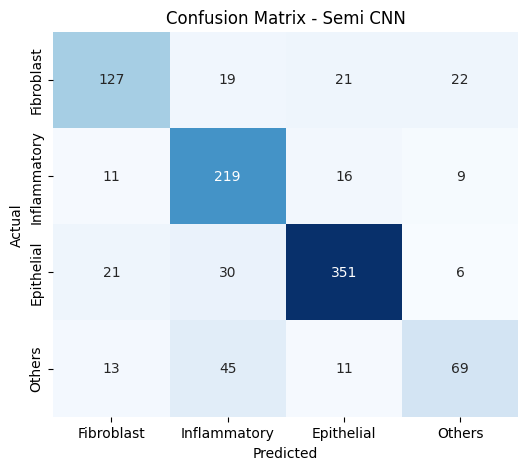

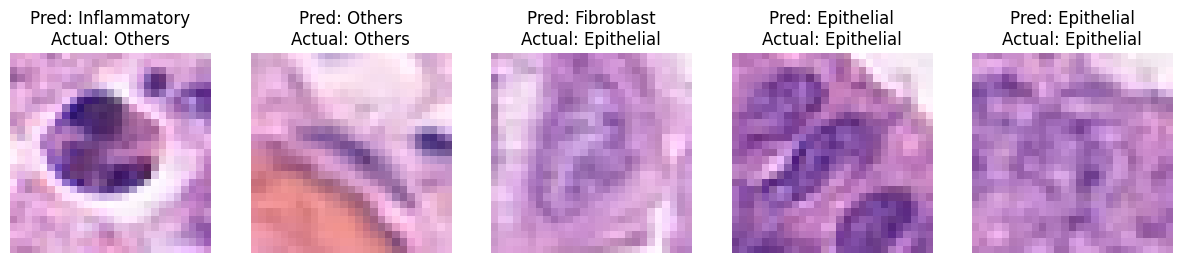

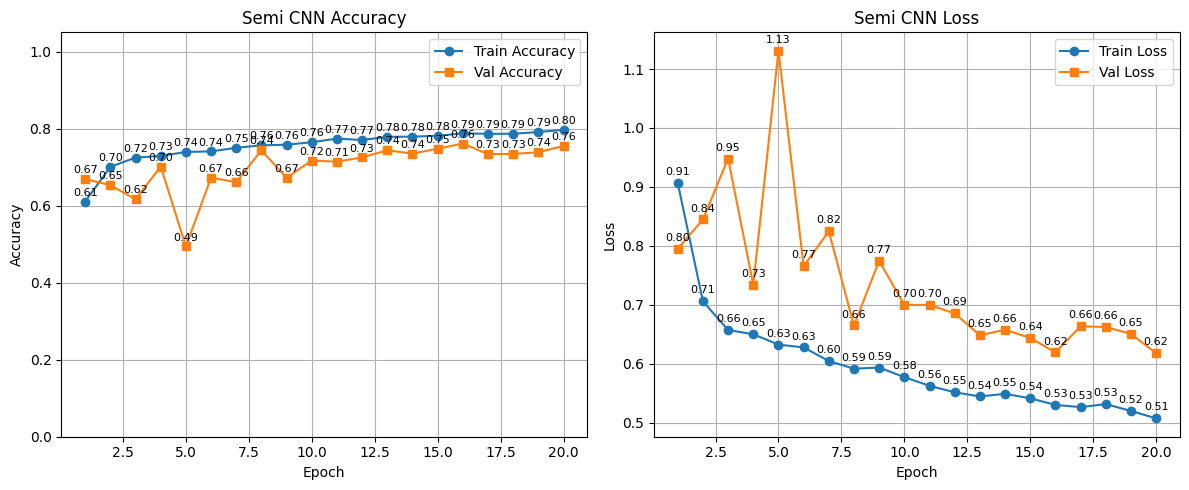

In [118]:
# Get predictions for the semi multi-class model
yCNN_probabilities = semi_model.predict(xTest)  # Use the semi CNN model
yCNN_pred = np.argmax(yCNN_probabilities, axis=1)  # Convert to class predictions (0–3)

# Evaluate model using the defined metrics (multi-class)
def evaluate_model(name, y_true, y_pred):
    print(f"\nEvaluation Metrics for {name}:")
    print("-" * 40)
    print("Accuracy       :", accuracy_score(y_true, y_pred))
    print("Precision (macro):", precision_score(y_true, y_pred, average='macro'))
    print("Recall (macro)   :", recall_score(y_true, y_pred, average='macro'))
    print("F1-Score (macro) :", f1_score(y_true, y_pred, average='macro'))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=['Fibroblast', 'Inflammatory', 'Epithelial', 'Others']))

# Display metrics for the semi CNN model
evaluate_model("Semi CNN", yTest, yCNN_pred)

# Plot Confusion Matrix for smi CNN (multi-class)
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    class_names = ['Fibroblast', 'Inflammatory', 'Epithelial', 'Others']
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

plot_conf_matrix(yTest, yCNN_pred, "Confusion Matrix - Semi CNN")

# Select random images from the test set for visualization
num_images = 5
random_indices = np.random.choice(len(xTest), num_images, replace=False)
class_names = ['Fibroblast', 'Inflammatory', 'Epithelial', 'Others']

plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    plt.subplot(1, num_images, i + 1)
    plt.imshow(xTest[idx])  # Display image
    plt.title(f"Pred: {class_names[yCNN_pred[idx]]}\nActual: {class_names[yTest[idx]]}")
    plt.axis('off')
plt.show()

# Plot Training and Validation Accuracy and Loss for the semi model
def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    epochs = range(1, len(history.history['accuracy']) + 1)
    plt.plot(epochs, history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(epochs, history.history['val_accuracy'], label='Val Accuracy', marker='s')

    # Annotate accuracy values
    for x, y in zip(epochs, history.history['accuracy']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
    for x, y in zip(epochs, history.history['val_accuracy']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)

    plt.title("Semi CNN Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history.history['val_loss'], label='Val Loss', marker='s')

    # Annotate loss values
    for x, y in zip(epochs, history.history['loss']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
    for x, y in zip(epochs, history.history['val_loss']):
        plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=8)

    plt.title("Semi CNN Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history_semi)

=> After applying the semi-supervised approach, the model showed a slight improvement in overall performance—accuracy and macro F1-score both increased. The Semi CNN also improved recall for the minority "Others" class from around 0.4 to 0.5, suggesting better generalisation through the use of unlabeled data.
However, both models still struggle with the "Others" class, which consistently shows the lowest F1-score (around 0.5). This limitation may affect downstream tasks. We believe that with more labelled data, especially for underrepresented classes, this performance could be further improved.

## Independent Evaluation

write something here if needed

## Comparative Analysis

write something here if needed

### Comparision with Baseline and Literature Models

write something here if needed

### Fairness and Consistency 

write something here if needed

## Critical Discussion

write something here if needed

### Insightful Discussion

write something here if needed

### Real-world Applicability

write something here if needed

# Conclusion

write conclusion here